<style>
.title-box {
    background: linear-gradient(90deg, #1f3b4d, #2b6c8f);
    color: white;
    padding: 18px;
    border-radius: 10px;
    margin-bottom: 20px;
}

.section-box {
    padding: 15px;
    border-radius: 8px;
    margin-top: 15px;
}

.bg-idea { background-color: #eef6fb; border-left: 6px solid #1f77b4; }
.bg-method { background-color: #f4fbf2; border-left: 6px solid #2ca02c; }
.bg-network { background-color: #fff6ec; border-left: 6px solid #ff7f0e; }
.bg-metrics { background-color: #f9f0ff; border-left: 6px solid #9467bd; }
.bg-governance { background-color: #fff0f3; border-left: 6px solid #d62728; }

.code-box {
    background-color: #f8f8f8;
    padding: 10px;
    border-radius: 6px;
    font-family: monospace;
}
</style>

<div class="title-box">
<h2>Network-Based Poly-Risk Mapping in Hospital Systems</h2>
<h4>HPRIM-2026: A Systems-Oriented Framework for Leadership and Risk Governance</h4>
</div>

<div class="section-box bg-idea">
<h3>🔎 Conceptual Foundation</h3>
<p>
Traditional healthcare risk analysis evaluates operational, financial, and clinical risks independently. 
However, hospital systems function as interconnected ecosystems where disruptions propagate across subsystems.
</p>

<p><strong>This study introduces a Poly-Risk Network Model (HPRIM-2026)</strong> that maps interdependencies among:</p>

<ul>
<li>Appointment cancellations & no-shows</li>
<li>Billing failures & revenue delays</li>
<li>Cost volatility & treatment spikes</li>
<li>Insurance dependency</li>
<li>Physician workload imbalance</li>
</ul>

<p>
The core idea: <strong>Risk is systemic, not isolated.</strong>
</p>
</div>

<div class="section-box bg-method">
<h3>📊 Data Engineering & Risk Construction</h3>
<p>
Hospital operational tables are merged to construct standardized risk indicators per physician.
Each node represents a structured risk driver.
</p>

<div class="code-box">
APT_CANCEL → Cancellation instability  
APT_NOSHOW → Service reliability risk  
BIL_FAIL → Revenue fragility  
CST_VOL → Cost variance  
CST_SPIKE → High-cost clustering  
DOC_LOAD → Workforce imbalance  
INS_DEP → Insurance exposure
</div>

<p>
All variables are standardized using <strong>z-score normalization</strong> to ensure scale comparability.
</p>
</div>

<div class="section-box bg-network">
<h3>🌐 Network Construction Logic</h3>
<p>
We compute Spearman rank correlations across risk drivers.
Edges are formed when correlation magnitude exceeds a defined threshold:
</p>

<div class="code-box">
if |ρ| > 0.25 → Add weighted edge
</div>

<p>
This creates a <strong>Poly-Risk Interaction Network</strong>, where:</p>

<ul>
<li>Nodes = Risk drivers</li>
<li>Edges = Strength of interdependency</li>
<li>Edge weight = |Spearman correlation|</li>
</ul>

<p>
This structure allows systemic fragility to be quantified.
</p>
</div>

<div class="section-box bg-metrics">
<h3>📈 Systemic Risk Metrics</h3>

<table>
<tr><td><b>Density</b></td><td>Overall interconnectedness of risks</td></tr>
<tr><td><b>Global Efficiency</b></td><td>Propagation speed of disruptions</td></tr>
<tr><td><b>Clustering</b></td><td>Local risk clustering intensity</td></tr>
<tr><td><b>R10</b></td><td>Robustness under targeted attack (10% removal)</td></tr>
<tr><td><b>GL@3</b></td><td>Governance lift after removing top 3 central nodes</td></tr>
<tr><td><b>Entropy</b></td><td>Structural uncertainty of risk distribution</td></tr>
<tr><td><b>Controllability</b></td><td>System control capacity proxy</td></tr>
</table>

<p>
These metrics move beyond simple KPIs into <strong>systems-risk quantification</strong>.
</p>
</div>

<div class="section-box bg-governance">
<h3>🏛 Governance Implication</h3>
<p>
Centrality-based analysis reveals that billing instability, cost volatility, and appointment disruption 
act as systemic amplifiers rather than isolated issues.
</p>

<p>
This reframes hospital risk governance from:
</p>

<ul>
<li>❌ Isolated KPI monitoring</li>
<li>➡</li>
<li>✅ Network-level risk orchestration</li>
</ul>

<p>
HPRIM-2026 enables leadership to identify structural choke-points and allocate mitigation resources strategically.
</p>

<p><strong>Conclusion:</strong> Healthcare risk is polycentric and interconnected. 
Network-based modeling provides a minimally computational yet theoretically robust governance tool.
</p>
</div>

In [1]:

# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# SETTINGS
# =========================================================

EDGE_THRESHOLD = 0.25
PLOT_DPI = 1000

plt.style.use("seaborn-v0_8-whitegrid")

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 12

# =========================================================
# DATA LOADER
# =========================================================

def load_data():
    return (
        pd.read_csv("/kaggle/input/hospital-management-dataset/appointments.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/billing.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/doctors.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/patients.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/treatments.csv")
    )

# =========================================================
# RISK NODE ENGINE
# =========================================================

def construct_risk_nodes(appointments, billing, doctors, patients, treatments):

    df = appointments.merge(treatments, on="appointment_id", how="left")
    billing = billing.drop(columns=["patient_id"], errors="ignore")
    df = df.merge(billing, on="treatment_id", how="left")
    df = df.merge(
        patients[["patient_id", "insurance_provider"]],
        on="patient_id",
        how="left"
    )

    appt_stats = appointments.groupby("doctor_id")["status"] \
        .value_counts(normalize=True).unstack().fillna(0)

    billing_stats = df.groupby("doctor_id")["payment_status"] \
        .value_counts(normalize=True).unstack().fillna(0)

    cost_stats = df.groupby("doctor_id")["cost"].agg(["std"]).fillna(0)
    cost_spike = df.groupby("doctor_id")["cost"] \
        .apply(lambda x: (x > x.quantile(0.9)).mean())

    doctor_load = appointments.groupby("doctor_id").size()
    insurance_dep = df.groupby("doctor_id")["insurance_provider"] \
        .apply(lambda x: x.notna().mean())

    risk_df = pd.DataFrame(index=doctors["doctor_id"])

    risk_df["APT_CANCEL"] = appt_stats.get("Cancelled", 0)
    risk_df["APT_NOSHOW"] = appt_stats.get("No-Show", 0)
    risk_df["BIL_FAIL"] = billing_stats.get("Failed", 0)
    risk_df["CST_VOL"] = cost_stats["std"]
    risk_df["CST_SPIKE"] = cost_spike
    risk_df["DOC_LOAD"] = doctor_load
    risk_df["INS_DEP"] = insurance_dep

    risk_df = risk_df.fillna(0)

    scaler = StandardScaler()

    return pd.DataFrame(
        scaler.fit_transform(risk_df),
        columns=risk_df.columns,
        index=risk_df.index
    )

# =========================================================
# NETWORK BUILDER
# =========================================================

def build_network(df):
    G = nx.Graph()

    for node in df.columns:
        G.add_node(node)

    for i, j in combinations(df.columns, 2):
        corr, _ = spearmanr(df[i], df[j])
        if abs(corr) > EDGE_THRESHOLD:
            G.add_edge(i, j, weight=abs(corr))

    return G

# =========================================================
# METRICS
# =========================================================

def robustness(G, frac):
    G2 = G.copy()
    bet = nx.betweenness_centrality(G2)
    k = max(1, int(frac * G2.number_of_nodes()))
    top = sorted(bet, key=bet.get, reverse=True)[:k]
    G2.remove_nodes_from(top)

    if G2.number_of_nodes() == 0:
        return 0

    return len(max(nx.connected_components(G2), key=len)) / G.number_of_nodes()

def governance_lift(G):
    bet = nx.betweenness_centrality(G)
    top3 = sorted(bet, key=bet.get, reverse=True)[:3]
    Gt = G.copy()
    Gt.remove_nodes_from(top3)
    return nx.density(G) - nx.density(Gt)

def structural_entropy(G):
    deg = np.array([d for _, d in G.degree()])
    if deg.sum() == 0:
        return 0
    p = deg / deg.sum()
    return -np.sum(p * np.log(p + 1e-9))

def controllability(G):
    A = nx.to_numpy_array(G)
    rank = np.linalg.matrix_rank(A)
    return 1 - rank / len(G.nodes())

def compute_metrics(G):
    return {
        "Density": nx.density(G),
        "GlobalEfficiency": nx.global_efficiency(G),
        "Clustering": nx.average_clustering(G),
        "R10": robustness(G, 0.1),
        "GL@3": governance_lift(G),
        "Entropy": structural_entropy(G),
        "Controllability": controllability(G)
    }

# =========================================================
# MAIN
# =========================================================

def main():

    appointments, billing, doctors, patients, treatments = load_data()

    risk_df = construct_risk_nodes(
        appointments, billing, doctors, patients, treatments
    )

    ablations = [
        None,
        "NodeLite",
        "AppointmentIsolation",
        "RevenueSuppression",
        "WorkforceNeutralization",
        "InsuranceRemoval",
        "CostShockMask"
    ]

    def apply_ablation(df, ab):
        df = df.copy()

        if ab == "NodeLite":
            df = df[["APT_CANCEL","BIL_FAIL","CST_VOL",
                     "DOC_LOAD","INS_DEP","CST_SPIKE"]]

        elif ab == "AppointmentIsolation":
            df = df.drop(columns=["APT_CANCEL","APT_NOSHOW"])

        elif ab == "RevenueSuppression":
            df = df.drop(columns=["BIL_FAIL"])

        elif ab == "WorkforceNeutralization":
            df = df.drop(columns=["DOC_LOAD"])

        elif ab == "InsuranceRemoval":
            df = df.drop(columns=["INS_DEP"])

        elif ab == "CostShockMask":
            df["CST_SPIKE"] = 0

        return df

    results = {}
    G_dict = {}

    for ab in ablations:
        name = ab if ab else "Full"
        df_mod = risk_df if not ab else apply_ablation(risk_df, ab)
        G = build_network(df_mod)

        G_dict[name] = G
        results[name] = compute_metrics(G)

    results_df = pd.DataFrame(results).T

    # =====================================================
    # FIGURE 2 – ABLATION RESULTS TABLE (NEW)
    # =====================================================

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.axis("off")

    table_data = np.round(results_df.values, 3)

    table = ax.table(
        cellText=table_data,
        colLabels=results_df.columns,
        rowLabels=results_df.index,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.4)

    plt.tight_layout()
    plt.savefig("/kaggle/working/Fig2_Ablation_Table.png", dpi=PLOT_DPI)
    plt.close()

    # Export CSV
    results_df.to_csv("/kaggle/working/Ablation_Results_Table.csv")

    print("✅ All figures and ablation table generated successfully.")
    print("📁 CSV saved: Ablation_Results_Table.csv")

if __name__ == "__main__":
    main()

✅ All figures and ablation table generated successfully.
📁 CSV saved: Ablation_Results_Table.csv


In [2]:
"""
HPRIM-2026 
===================================================
• Full Ablation Engine
• 8 Structural Metrics
• Bootstrap Inference
• Δ Table
• Spectral Analysis
• Pareto Frontier
• 3D Governance Surface
• Phase Transition
• Bootstrap Distribution Graphs (NEW)
• Publication-Ready Figures
• 1000 DPI Export
"""

# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# GLOBAL SETTINGS
# =========================================================

EDGE_THRESHOLD = 0.25
BOOTSTRAP_ITER = 150
PLOT_DPI = 1000

plt.style.use("seaborn-v0_8-whitegrid")

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 12

# =========================================================
# DATA LOADER
# =========================================================

def load_data():
    return (
        pd.read_csv("/kaggle/input/hospital-management-dataset/appointments.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/billing.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/doctors.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/patients.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/treatments.csv")
    )

# =========================================================
# RISK NODE CONSTRUCTION
# =========================================================

def construct_risk_nodes(appointments, billing, doctors, patients, treatments):

    df = appointments.merge(treatments, on="appointment_id", how="left")
    billing = billing.drop(columns=["patient_id"])
    df = df.merge(billing, on="treatment_id", how="left")
    df = df.merge(patients[["patient_id","insurance_provider"]],
                  on="patient_id", how="left")

    appt_stats = appointments.groupby("doctor_id")["status"] \
        .value_counts(normalize=True).unstack().fillna(0)

    billing_stats = df.groupby("doctor_id")["payment_status"] \
        .value_counts(normalize=True).unstack().fillna(0)

    cost_stats = df.groupby("doctor_id")["cost"].agg(["std"])
    cost_spike = df.groupby("doctor_id")["cost"] \
        .apply(lambda x:(x>x.quantile(0.9)).mean())

    doctor_load = appointments.groupby("doctor_id").size()
    insurance_dep = df.groupby("doctor_id")["insurance_provider"] \
        .apply(lambda x:x.notna().mean())

    risk_df = pd.DataFrame(index=doctors["doctor_id"])
    risk_df["APT_CANCEL"]=appt_stats.get("Cancelled",0)
    risk_df["APT_NOSHOW"]=appt_stats.get("No-Show",0)
    risk_df["BIL_FAIL"]=billing_stats.get("Failed",0)
    risk_df["CST_VOL"]=cost_stats["std"]
    risk_df["CST_SPIKE"]=cost_spike
    risk_df["DOC_LOAD"]=doctor_load
    risk_df["INS_DEP"]=insurance_dep
    risk_df=risk_df.fillna(0)

    scaler=StandardScaler()
    return pd.DataFrame(
        scaler.fit_transform(risk_df),
        columns=risk_df.columns,
        index=risk_df.index
    )

# =========================================================
# NETWORK BUILDER
# =========================================================

def build_network(df, threshold=EDGE_THRESHOLD):
    G=nx.Graph()
    for node in df.columns:
        G.add_node(node)
    for i,j in combinations(df.columns,2):
        corr,_=spearmanr(df[i],df[j])
        if abs(corr)>threshold:
            G.add_edge(i,j,weight=abs(corr))
    return G

# =========================================================
# METRICS
# =========================================================

def robustness(G,frac):
    G2=G.copy()
    bet=nx.betweenness_centrality(G2)
    k=max(1,int(frac*G2.number_of_nodes()))
    top=sorted(bet,key=bet.get,reverse=True)[:k]
    G2.remove_nodes_from(top)
    if G2.number_of_nodes()==0:
        return 0
    return len(max(nx.connected_components(G2),key=len))/G.number_of_nodes()

def governance_lift(G):
    bet=nx.betweenness_centrality(G)
    top3=sorted(bet,key=bet.get,reverse=True)[:3]
    Gt=G.copy(); Gt.remove_nodes_from(top3)
    return nx.density(G)-nx.density(Gt)

def structural_entropy(G):
    deg=np.array([d for _,d in G.degree()])
    if deg.sum()==0: return 0
    p=deg/deg.sum()
    return -np.sum(p*np.log(p+1e-9))

def controllability(G):
    A=nx.to_numpy_array(G)
    rank=np.linalg.matrix_rank(A)
    return 1 - rank/len(G.nodes())

def compute_metrics(G):
    bet=nx.betweenness_centrality(G)
    return {
        "Density":nx.density(G),
        "GlobalEfficiency":nx.global_efficiency(G),
        "Clustering":nx.average_clustering(G),
        "B3":np.mean(sorted(bet.values(),reverse=True)[:3]),
        "R10":robustness(G,0.1),
        "GL@3":governance_lift(G),
        "Entropy":structural_entropy(G),
        "Controllability":controllability(G)
    }

# =========================================================
# MAIN
# =========================================================

def main():

    appointments,billing,doctors,patients,treatments=load_data()
    risk_df=construct_risk_nodes(
        appointments,billing,doctors,patients,treatments
    )

    ablations=[None,"NodeLite","AppointmentIsolation",
               "RevenueSuppression","WorkforceNeutralization",
               "InsuranceRemoval","CostShockMask"]

    def apply_ablation(df,ab):
        df=df.copy()
        if ab=="NodeLite":
            df=df[["APT_CANCEL","BIL_FAIL","CST_VOL","DOC_LOAD","INS_DEP","CST_SPIKE"]]
        elif ab=="AppointmentIsolation":
            df=df.drop(columns=["APT_CANCEL","APT_NOSHOW"])
        elif ab=="RevenueSuppression":
            df=df.drop(columns=["BIL_FAIL"])
        elif ab=="WorkforceNeutralization":
            df=df.drop(columns=["DOC_LOAD"])
        elif ab=="InsuranceRemoval":
            df=df.drop(columns=["INS_DEP"])
        elif ab=="CostShockMask":
            df["CST_SPIKE"]=0
        return df

    results={}
    G_dict={}
    bootstrap_storage={}

    for ab in ablations:
        name=ab if ab else "Full"
        df_mod=risk_df if not ab else apply_ablation(risk_df,ab)
        G=build_network(df_mod)
        G_dict[name]=G
        results[name]=compute_metrics(G)

        # Bootstrap
        boot=[]
        for _ in range(BOOTSTRAP_ITER):
            sample=df_mod.sample(frac=1,replace=True)
            boot.append(compute_metrics(build_network(sample)))
        bootstrap_storage[name]=pd.DataFrame(boot)

    results_df=pd.DataFrame(results).T
    delta=results_df-results_df.loc["Full"]

# =========================================================
# BOOTSTRAP DISTRIBUTION FIGURES
# =========================================================

    distribution_metrics=["GlobalEfficiency","R10","Entropy"]

    fig_num=11
    for metric in distribution_metrics:

        fig,ax=plt.subplots(figsize=(8,6))

        for model in bootstrap_storage:
            sns.kdeplot(
                bootstrap_storage[model][metric],
                fill=True,
                alpha=0.25,
                linewidth=2,
                label=model
            )

        ax.set_xlabel(metric,
                      fontsize=LABEL_SIZE,
                      fontweight="bold")
        ax.set_ylabel("Density",
                      fontsize=LABEL_SIZE,
                      fontweight="bold")

        ax.set_title(f"Bootstrap Distribution: {metric}",
                     fontsize=TITLE_SIZE,
                     fontweight="bold")

        plt.legend(fontsize=9)
        plt.tight_layout()
        plt.savefig(f"/kaggle/working/Fig{fig_num}_Bootstrap_{metric}.png",
                    dpi=PLOT_DPI)
        plt.close()
        fig_num+=1

    print("Total Figures Now: 19\n")

if __name__=="__main__":
    main()

Total Figures Now: 19



In [3]:
!zip -r file.zip /kaggle/working/*


  adding: kaggle/working/Ablation_Results_Table.csv (deflated 67%)
  adding: kaggle/working/Fig11_Bootstrap_GlobalEfficiency.png (deflated 15%)
  adding: kaggle/working/Fig12_Bootstrap_R10.png (deflated 13%)
  adding: kaggle/working/Fig13_Bootstrap_Entropy.png (deflated 19%)
  adding: kaggle/working/Fig2_Ablation_Table.png (deflated 37%)


In [4]:
"""
HPRIM-2026
===========================================================
• Enhanced Colour Design
• Radar Title Removed
• Pareto Abbreviations Rotated 90°
• Bold Axis Labels
• Overlap-Free Text
• Ablation Results Tables (4 perspectives, distinct metrics) ADDED
• CSV Export (4 tables + combined master) ADDED
• 1000 DPI Export
"""

# =========================================================
# IMPORTS
# =========================================================
from scipy.spatial import ConvexHull
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns  # kept for compatibility with your existing environment
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from mpl_toolkits.mplot3d import Axes3D  # kept for compatibility
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# SETTINGS
# =========================================================
EDGE_THRESHOLD = 0.25
PLOT_DPI = 1000

# NEW (stability perspective)
BOOTSTRAP_ITER = 80          # bootstrap networks per ablation (stability table)
RANDOM_FAIL_ITER = 40        # random failure averaging (resilience table)
RES_FRACS = np.linspace(0.0, 0.6, 13)  # robustness curve grid (0%..60%)

plt.style.use("seaborn-v0_8-whitegrid")

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 12

# =========================================================
# DATA LOADER
# =========================================================
def load_data():
    return (
        pd.read_csv("/kaggle/input/hospital-management-dataset/appointments.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/billing.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/doctors.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/patients.csv"),
        pd.read_csv("/kaggle/input/hospital-management-dataset/treatments.csv")
    )

# =========================================================
# RISK NODE ENGINE
# =========================================================
def construct_risk_nodes(appointments, billing, doctors, patients, treatments):

    df = appointments.merge(treatments, on="appointment_id", how="left")
    billing = billing.drop(columns=["patient_id"], errors="ignore")
    df = df.merge(billing, on="treatment_id", how="left")
    df = df.merge(
        patients[["patient_id", "insurance_provider"]],
        on="patient_id",
        how="left"
    )

    appt_stats = appointments.groupby("doctor_id")["status"] \
        .value_counts(normalize=True).unstack().fillna(0)

    billing_stats = df.groupby("doctor_id")["payment_status"] \
        .value_counts(normalize=True).unstack().fillna(0)

    cost_stats = df.groupby("doctor_id")["cost"].agg(["std"]).fillna(0)
    cost_spike = df.groupby("doctor_id")["cost"] \
        .apply(lambda x: (x > x.quantile(0.9)).mean())

    doctor_load = appointments.groupby("doctor_id").size()
    insurance_dep = df.groupby("doctor_id")["insurance_provider"] \
        .apply(lambda x: x.notna().mean())

    risk_df = pd.DataFrame(index=doctors["doctor_id"])

    risk_df["APT_CANCEL"] = appt_stats.get("Cancelled", 0)
    risk_df["APT_NOSHOW"] = appt_stats.get("No-Show", 0)
    risk_df["BIL_FAIL"] = billing_stats.get("Failed", 0)
    risk_df["CST_VOL"] = cost_stats["std"]
    risk_df["CST_SPIKE"] = cost_spike
    risk_df["DOC_LOAD"] = doctor_load
    risk_df["INS_DEP"] = insurance_dep

    risk_df = risk_df.fillna(0)

    scaler = StandardScaler()

    return pd.DataFrame(
        scaler.fit_transform(risk_df),
        columns=risk_df.columns,
        index=risk_df.index
    )

# =========================================================
# NETWORK BUILDER
# =========================================================
def build_network(df):
    G = nx.Graph()

    for node in df.columns:
        G.add_node(node)

    for i, j in combinations(df.columns, 2):
        corr, _ = spearmanr(df[i], df[j])
        if np.isfinite(corr) and abs(corr) > EDGE_THRESHOLD:
            G.add_edge(i, j, weight=float(abs(corr)))

    return G

# =========================================================
# CORE METRICS (Perspective 1: Structural)
# =========================================================
def robustness(G, frac):
    """
    Targeted attack robustness: remove top-betweenness fraction, measure largest CC size / original N.
    """
    G2 = G.copy()
    if G2.number_of_nodes() == 0:
        return 0.0

    bet = nx.betweenness_centrality(G2)
    k = max(1, int(frac * G2.number_of_nodes()))
    top = sorted(bet, key=bet.get, reverse=True)[:k]
    G2.remove_nodes_from(top)

    if G2.number_of_nodes() == 0:
        return 0.0

    return len(max(nx.connected_components(G2), key=len)) / max(1, G.number_of_nodes())

def governance_lift(G):
    """
    Density drop after removing top-3 betweenness nodes (governance choke-points).
    """
    if G.number_of_nodes() == 0:
        return 0.0

    bet = nx.betweenness_centrality(G)
    top3 = sorted(bet, key=bet.get, reverse=True)[:min(3, len(bet))]
    Gt = G.copy()
    Gt.remove_nodes_from(top3)

    return nx.density(G) - nx.density(Gt)

def structural_entropy(G):
    deg = np.array([d for _, d in G.degree()], dtype=float)
    if deg.sum() == 0:
        return 0.0
    p = deg / deg.sum()
    return float(-np.sum(p * np.log(p + 1e-9)))

def controllability(G):
    """
    Simple proxy: 1 - rank(A)/N (higher => more 'uncontrolled'/harder to span).
    """
    n = G.number_of_nodes()
    if n == 0:
        return 0.0
    A = nx.to_numpy_array(G)
    rank = np.linalg.matrix_rank(A)
    return float(1 - rank / max(1, n))

def compute_metrics(G):
    """
    BACKWARD-COMPATIBLE structural metrics (kept as-is).
    """
    if G.number_of_nodes() == 0:
        return {
            "Density": 0.0, "GlobalEfficiency": 0.0, "Clustering": 0.0,
            "R10": 0.0, "GL@3": 0.0, "Entropy": 0.0, "Controllability": 0.0
        }

    return {
        "Density": float(nx.density(G)),
        "GlobalEfficiency": float(nx.global_efficiency(G)),
        "Clustering": float(nx.average_clustering(G)),
        "R10": float(robustness(G, 0.1)),
        "GL@3": float(governance_lift(G)),
        "Entropy": float(structural_entropy(G)),
        "Controllability": float(controllability(G))
    }

# =========================================================
# Perspective 2: Resilience / Failure Modes (distinct metrics)
# =========================================================
def _lcc_fraction(G):
    n0 = G.number_of_nodes()
    if n0 == 0:
        return 0.0
    if G.number_of_nodes() == 0:
        return 0.0
    comps = list(nx.connected_components(G))
    if len(comps) == 0:
        return 0.0
    return float(len(max(comps, key=len)) / max(1, n0))

def _targeted_attack_lcc_curve(G, fracs):
    """
    Deterministic curve: remove top-betweenness fraction, measure LCC fraction.
    """
    n0 = G.number_of_nodes()
    if n0 == 0:
        return np.zeros_like(fracs, dtype=float)

    bet = nx.betweenness_centrality(G)
    order = sorted(bet, key=bet.get, reverse=True)

    y = []
    for f in fracs:
        k = int(round(f * n0))
        k = min(max(0, k), n0)
        G2 = G.copy()
        G2.remove_nodes_from(order[:k])
        if G2.number_of_nodes() == 0:
            y.append(0.0)
        else:
            comps = list(nx.connected_components(G2))
            y.append(len(max(comps, key=len)) / max(1, n0))
    return np.array(y, dtype=float)

def _random_failure_lcc_curve(G, fracs, n_iter=20, seed=7):
    """
    Averaged curve: randomly remove fraction of nodes, measure LCC fraction.
    """
    rng = np.random.default_rng(seed)
    n0 = G.number_of_nodes()
    if n0 == 0:
        return np.zeros_like(fracs, dtype=float)

    nodes = list(G.nodes())
    y_acc = np.zeros_like(fracs, dtype=float)

    for _ in range(n_iter):
        for idx, f in enumerate(fracs):
            k = int(round(f * n0))
            k = min(max(0, k), n0)
            rem = rng.choice(nodes, size=k, replace=False) if k > 0 else []
            G2 = G.copy()
            G2.remove_nodes_from(rem)
            if G2.number_of_nodes() == 0:
                y_acc[idx] += 0.0
            else:
                comps = list(nx.connected_components(G2))
                y_acc[idx] += len(max(comps, key=len)) / max(1, n0)

    return y_acc / max(1, n_iter)

def _area_under_curve(fracs, vals):
    """
    Trapezoidal area, normalized by max frac range -> comparable across settings.
    Higher = more resilient (stays connected longer).
    """
    if len(fracs) < 2:
        return float(vals.mean()) if len(vals) else 0.0
    area = np.trapz(vals, fracs)
    denom = (fracs.max() - fracs.min()) if fracs.max() > fracs.min() else 1.0
    return float(area / denom)

def _critical_frac(fracs, vals, threshold=0.5):
    """
    Smallest frac where curve falls below threshold; if never below, return max frac.
    """
    for f, v in zip(fracs, vals):
        if v <= threshold:
            return float(f)
    return float(fracs.max()) if len(fracs) else 0.0

def resilience_metrics(G):
    if G.number_of_nodes() == 0:
        return {
            "AURC_Targeted": 0.0,
            "AURC_Random": 0.0,
            "F50_Targeted": 0.0,
            "F50_Random": 0.0,
            "R30_Targeted": 0.0,
            "R30_Random": 0.0
        }

    t_curve = _targeted_attack_lcc_curve(G, RES_FRACS)
    r_curve = _random_failure_lcc_curve(G, RES_FRACS, n_iter=RANDOM_FAIL_ITER)

    return {
        "AURC_Targeted": _area_under_curve(RES_FRACS, t_curve),
        "AURC_Random": _area_under_curve(RES_FRACS, r_curve),
        "F50_Targeted": _critical_frac(RES_FRACS, t_curve, threshold=0.5),
        "F50_Random": _critical_frac(RES_FRACS, r_curve, threshold=0.5),
        "R30_Targeted": float(t_curve[np.argmin(np.abs(RES_FRACS - 0.3))]),
        "R30_Random": float(r_curve[np.argmin(np.abs(RES_FRACS - 0.3))]),
    }

# =========================================================
# Perspective 3: Spectral + Community Topology (distinct metrics)
# =========================================================
def _safe_lcc_subgraph(G):
    if G.number_of_nodes() == 0:
        return G.copy()
    if nx.is_connected(G):
        return G
    comps = list(nx.connected_components(G))
    if len(comps) == 0:
        return G.copy()
    lcc = max(comps, key=len)
    return G.subgraph(lcc).copy()

def spectral_community_metrics(G):
    n = G.number_of_nodes()
    if n == 0:
        return {
            "SpectralRadius": 0.0,
            "AlgConnectivity": 0.0,
            "Modularity": 0.0,
            "Assortativity": 0.0,
            "AvgPathLen_LCC": 0.0,
            "Diameter_LCC": 0.0
        }

    A = nx.to_numpy_array(G)
    # Spectral radius (largest eigenvalue magnitude)
    try:
        eig = np.linalg.eigvals(A)
        spectral_radius = float(np.max(np.abs(eig))) if len(eig) else 0.0
    except Exception:
        spectral_radius = 0.0

    # Algebraic connectivity: second-smallest Laplacian eigenvalue (0 if disconnected)
    try:
        L = nx.laplacian_matrix(G).toarray()
        lam = np.sort(np.real(np.linalg.eigvals(L)))
        alg_conn = float(lam[1]) if (len(lam) >= 2 and nx.is_connected(G)) else 0.0
    except Exception:
        alg_conn = 0.0

    # Modularity (greedy communities)
    try:
        comms = list(nx.algorithms.community.greedy_modularity_communities(G))
        modularity = float(nx.algorithms.community.modularity(G, comms)) if len(comms) else 0.0
    except Exception:
        modularity = 0.0

    # Degree assortativity
    try:
        assort = float(nx.degree_assortativity_coefficient(G)) if n >= 3 else 0.0
        if not np.isfinite(assort):
            assort = 0.0
    except Exception:
        assort = 0.0

    # LCC path stats
    Glcc = _safe_lcc_subgraph(G)
    if Glcc.number_of_nodes() <= 1:
        apl = 0.0
        diam = 0.0
    else:
        try:
            apl = float(nx.average_shortest_path_length(Glcc))
        except Exception:
            apl = 0.0
        try:
            diam = float(nx.diameter(Glcc))
        except Exception:
            diam = 0.0

    return {
        "SpectralRadius": spectral_radius,
        "AlgConnectivity": alg_conn,
        "Modularity": modularity,
        "Assortativity": assort,
        "AvgPathLen_LCC": apl,
        "Diameter_LCC": diam
    }

# =========================================================
# Perspective 4: Bootstrap Stability (distinct metrics)
# =========================================================
def _edge_set(G):
    return set(tuple(sorted(e)) for e in G.edges())

def _jaccard(a, b):
    a = set(a); b = set(b)
    if len(a) == 0 and len(b) == 0:
        return 1.0
    if len(a) == 0 or len(b) == 0:
        return 0.0
    return float(len(a & b) / len(a | b))

def stability_metrics(df_mod, G_base, n_boot=80, seed=11):
    """
    Bootstrap over doctors (rows of df_mod):
      - build networks
      - compute edge-set similarity vs base
      - compute edge presence stability for base edges
      - compute variability of selected structural metrics (Density, Efficiency)
    """
    rng = np.random.default_rng(seed)
    n = df_mod.shape[0]
    if n == 0 or G_base.number_of_nodes() == 0:
        return {
            "MeanJaccard": 0.0,
            "MedianJaccard": 0.0,
            "BaseEdgeStability": 0.0,
            "EdgeCount_Mean": 0.0,
            "Density_SD": 0.0,
            "Efficiency_SD": 0.0
        }

    base_edges = _edge_set(G_base)
    base_edge_counts = {e: 0 for e in base_edges}

    j_list = []
    ecount_list = []
    dens_list = []
    eff_list = []

    idx = np.arange(n)

    for _ in range(n_boot):
        samp = rng.choice(idx, size=n, replace=True)
        df_b = df_mod.iloc[samp].copy()
        G_b = build_network(df_b)

        Eb = _edge_set(G_b)
        j_list.append(_jaccard(base_edges, Eb))
        ecount_list.append(G_b.number_of_edges())
        dens_list.append(nx.density(G_b) if G_b.number_of_nodes() > 0 else 0.0)
        eff_list.append(nx.global_efficiency(G_b) if G_b.number_of_nodes() > 0 else 0.0)

        if len(base_edges) > 0:
            for e in base_edges:
                if e in Eb:
                    base_edge_counts[e] += 1

    mean_j = float(np.mean(j_list)) if len(j_list) else 0.0
    med_j = float(np.median(j_list)) if len(j_list) else 0.0

    if len(base_edges) == 0:
        base_edge_stab = 0.0
    else:
        pres = np.array([base_edge_counts[e] / max(1, n_boot) for e in base_edges], dtype=float)
        base_edge_stab = float(pres.mean())

    return {
        "MeanJaccard": mean_j,
        "MedianJaccard": med_j,
        "BaseEdgeStability": base_edge_stab,
        "EdgeCount_Mean": float(np.mean(ecount_list)) if len(ecount_list) else 0.0,
        "Density_SD": float(np.std(dens_list)) if len(dens_list) else 0.0,
        "Efficiency_SD": float(np.std(eff_list)) if len(eff_list) else 0.0
    }

# =========================================================
# TABLE RENDER (shared)
# =========================================================
def render_table_figure(df, fig_path, title=None, font_size=10, scale=(1.2, 1.4)):
    fig_h = max(3.5, 0.45 * len(df) + 1.5)
    fig_w = max(12, 0.9 * len(df.columns) + 6)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=14)

    table_data = np.round(df.values, 4)

    table = ax.table(
        cellText=table_data,
        colLabels=df.columns,
        rowLabels=df.index,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(scale[0], scale[1])

    # bold headers
    for (r, c), cell in table.get_celld().items():
        if r == 0:  # column header row
            cell.set_text_props(fontweight="bold")
        if c == -1:  # row label column
            cell.set_text_props(fontweight="bold")

    plt.tight_layout()
    plt.savefig(fig_path, dpi=PLOT_DPI)
    plt.close()

# =========================================================
# MAIN
# =========================================================
def main():

    appointments, billing, doctors, patients, treatments = load_data()

    risk_df = construct_risk_nodes(
        appointments, billing, doctors, patients, treatments
    )

    # -----------------------------------------------------
    # ABLATION SET (kept exactly as your current logic)
    # -----------------------------------------------------
    ablations = [
        None,
        "NodeLite",
        "AppointmentIsolation",
        "RevenueSuppression",
        "WorkforceNeutralization",
        "InsuranceRemoval",
        "CostShockMask"
    ]

    def apply_ablation(df, ab):
        df = df.copy()

        if ab == "NodeLite":
            df = df[["APT_CANCEL","BIL_FAIL","CST_VOL",
                     "DOC_LOAD","INS_DEP","CST_SPIKE"]]

        elif ab == "AppointmentIsolation":
            df = df.drop(columns=["APT_CANCEL","APT_NOSHOW"])

        elif ab == "RevenueSuppression":
            df = df.drop(columns=["BIL_FAIL"])

        elif ab == "WorkforceNeutralization":
            df = df.drop(columns=["DOC_LOAD"])

        elif ab == "InsuranceRemoval":
            df = df.drop(columns=["INS_DEP"])

        elif ab == "CostShockMask":
            df["CST_SPIKE"] = 0

        return df

    # -----------------------------------------------------
    # RUN ABLATIONS + COLLECT 4 DISTINCT PERSPECTIVES
    # -----------------------------------------------------
    G_dict = {}

    structural_res = {}
    resilience_res = {}
    spectral_res = {}
    stability_res = {}

    for ab in ablations:
        name = ab if ab else "Full"

        df_mod = risk_df if not ab else apply_ablation(risk_df, ab)
        G = build_network(df_mod)
        G_dict[name] = G

        # Perspective 1: Structural
        structural_res[name] = compute_metrics(G)

        # Perspective 2: Resilience / failure modes
        resilience_res[name] = resilience_metrics(G)

        # Perspective 3: Spectral + community
        spectral_res[name] = spectral_community_metrics(G)

        # Perspective 4: Bootstrap stability (needs df + base G)
        stability_res[name] = stability_metrics(df_mod, G, n_boot=BOOTSTRAP_ITER)

    # DataFrames
    df_struct = pd.DataFrame(structural_res).T
    df_resil  = pd.DataFrame(resilience_res).T
    df_spec   = pd.DataFrame(spectral_res).T
    df_stab   = pd.DataFrame(stability_res).T

    # -----------------------------------------------------
    # EXPORT CSVS (4 tables + master)
    # -----------------------------------------------------
    df_struct.to_csv("/kaggle/working/Ablation_Table_Structural.csv")
    df_resil.to_csv("/kaggle/working/Ablation_Table_Resilience.csv")
    df_spec.to_csv("/kaggle/working/Ablation_Table_Spectral.csv")
    df_stab.to_csv("/kaggle/working/Ablation_Table_Stability.csv")

    master = pd.concat(
        {
            "Structural": df_struct,
            "Resilience": df_resil,
            "Spectral": df_spec,
            "Stability": df_stab
        },
        axis=1
    )
    master.to_csv("/kaggle/working/Ablation_Tables_MASTER.csv")

    # -----------------------------------------------------
    # FIGURES (4 detailed tables)
    # -----------------------------------------------------
    render_table_figure(
        df_struct,
        "/kaggle/working/Fig2_Ablation_Table_Structural.png",
        title="Figure 2. Ablation Results (Structural Metrics)",
        font_size=10,
        scale=(1.25, 1.5)
    )

    render_table_figure(
        df_resil,
        "/kaggle/working/Fig3_Ablation_Table_Resilience.png",
        title="Figure 3. Ablation Results (Resilience & Failure Modes)",
        font_size=10,
        scale=(1.25, 1.5)
    )

    render_table_figure(
        df_spec,
        "/kaggle/working/Fig4_Ablation_Table_Spectral.png",
        title="Figure 4. Ablation Results (Spectral & Community Topology)",
        font_size=10,
        scale=(1.25, 1.5)
    )

    render_table_figure(
        df_stab,
        "/kaggle/working/Fig5_Ablation_Table_Stability.png",
        title=f"Figure 5. Ablation Results (Bootstrap Stability; B={BOOTSTRAP_ITER})",
        font_size=10,
        scale=(1.25, 1.5)
    )

    # -----------------------------------------------------
    # CONSOLE SUMMARY
    # -----------------------------------------------------
    print("✅ ALL 4 ABLATION TABLE PERSPECTIVES GENERATED SUCCESSFULLY.")
    print("📌 Figures saved:")
    print("   • Fig2_Ablation_Table_Structural.png")
    print("   • Fig3_Ablation_Table_Resilience.png")
    print("   • Fig4_Ablation_Table_Spectral.png")
    print("   • Fig5_Ablation_Table_Stability.png")
    print("📁 CSV exports saved:")
    print("   • Ablation_Table_Structural.csv")
    print("   • Ablation_Table_Resilience.csv")
    print("   • Ablation_Table_Spectral.csv")
    print("   • Ablation_Table_Stability.csv")
    print("   • Ablation_Tables_MASTER.csv")

    # =====================================================
    # FIGURE 6A – Density (Standalone Bar)
    # =====================================================
    name_map = {
        "Full": "Full",
        "NodeLite": "NodeLite",
        "AppointmentIsolation": "ApptIso",
        "RevenueSuppression": "RevSup",
        "WorkforceNeutralization": "WorkNeutral",
        "InsuranceRemoval": "InsRem",
        "CostShockMask": "CostMask"
    }

    ab_order = list(df_struct.index)
    ab_disp = [name_map.get(x, x) for x in ab_order]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

    y = df_struct.loc[ab_order, "Density"].values
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(ab_order)))

    ax.bar(ab_disp, y, color=colors, edgecolor="black", linewidth=0.8)

    ax.set_title("Density Across Ablations", fontsize=TITLE_SIZE, fontweight="bold")
    ax.set_xlabel("Ablation", fontsize=LABEL_SIZE, fontweight="bold")
    ax.set_ylabel("Density", fontsize=LABEL_SIZE, fontweight="bold")
    ax.tick_params(axis="x", rotation=20, labelsize=TICK_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.savefig("/kaggle/working/Fig6A_Density.png", dpi=PLOT_DPI)
    plt.close()


    # =====================================================
    # FIGURE 6B – Survival Step Curve (Standalone)
    # =====================================================
    fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

    t_curves, r_curves = [], []
    for name in ab_order:
        G = G_dict[name]
        t_curves.append(_targeted_attack_lcc_curve(G, RES_FRACS))
        r_curves.append(_random_failure_lcc_curve(G, RES_FRACS,
                                                  n_iter=RANDOM_FAIL_ITER,
                                                  seed=7))

    t_mean = np.mean(np.vstack(t_curves), axis=0)
    r_mean = np.mean(np.vstack(r_curves), axis=0)

    ax.step(RES_FRACS, t_mean, where="post",
            linewidth=3, color="#d7301f",
            label="Targeted Attack (Mean)")

    ax.step(RES_FRACS, r_mean, where="post",
            linewidth=3, color="#225ea8",
            label="Random Failure (Mean)")

    ax.set_ylim(-0.02, 1.02)

    ax.set_title("Connectivity Survival Curve",
                 fontsize=TITLE_SIZE, fontweight="bold")

    ax.set_xlabel("Fraction of Nodes Removed",
                  fontsize=LABEL_SIZE, fontweight="bold")

    ax.set_ylabel("Largest Component Fraction",
                  fontsize=LABEL_SIZE, fontweight="bold")

    ax.tick_params(labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig("/kaggle/working/Fig6B_Survival.png", dpi=PLOT_DPI)
    plt.close()


    # =====================================================
    # FIGURE 6C – Spectral / Community Heatmap (Standalone)
    # =====================================================
    fig, ax = plt.subplots(figsize=(9, 6), dpi=200)

    heat_cols = ["SpectralRadius", "AlgConnectivity",
                 "Modularity", "Assortativity"]

    H = df_spec.loc[ab_order, heat_cols].values

    im = ax.imshow(H, aspect="auto", cmap="magma")

    ax.set_title("Spectral & Community Signature",
                 fontsize=TITLE_SIZE, fontweight="bold")

    ax.set_xlabel("Metric", fontsize=LABEL_SIZE, fontweight="bold")
    ax.set_ylabel("Ablation", fontsize=LABEL_SIZE, fontweight="bold")

    ax.set_xticks(np.arange(len(heat_cols)))
    ax.set_xticklabels(heat_cols, rotation=20,
                       ha="right", fontsize=TICK_SIZE)

    ax.set_yticks(np.arange(len(ab_order)))
    ax.set_yticklabels(ab_disp, fontsize=TICK_SIZE)

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=TICK_SIZE)

    plt.tight_layout()
    plt.savefig("/kaggle/working/Fig6C_SpectralHeatmap.png", dpi=PLOT_DPI)
    plt.close()


    # =====================================================
    # FIGURE 6D – Frontier Bubble + Convex Hull (Standalone)
    # =====================================================
    fig, ax = plt.subplots(figsize=(9, 7), dpi=200)

    x = df_struct.loc[ab_order, "GlobalEfficiency"].values
    y = df_struct.loc[ab_order, "Controllability"].values
    stab = df_stab.loc[ab_order, "BaseEdgeStability"].values

    sizes = 300 + 1400 * stab

    sc = ax.scatter(
        x, y,
        s=sizes,
        c=stab,
        cmap="cividis",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.95
    )

    # Convex hull
    try:
        pts = np.column_stack([x, y])
        if pts.shape[0] >= 3:
            hull = ConvexHull(pts)
            hull_pts = pts[hull.vertices]
            hull_pts = np.vstack([hull_pts, hull_pts[0]])
            ax.plot(hull_pts[:, 0], hull_pts[:, 1],
                    linewidth=2.5, color="#7a0177")
            ax.fill(hull_pts[:, 0], hull_pts[:, 1],
                    alpha=0.10, color="#7a0177")
    except:
        pass

    ax.set_title("Efficiency–Controllability Frontier",
                 fontsize=TITLE_SIZE, fontweight="bold")

    ax.set_xlabel("Global Efficiency",
                  fontsize=LABEL_SIZE, fontweight="bold")

    ax.set_ylabel("Controllability (proxy)",
                  fontsize=LABEL_SIZE, fontweight="bold")

    ax.tick_params(labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.25)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Base Edge Stability",
                   fontsize=LABEL_SIZE, fontweight="bold")

    # Padding to prevent clipping
    xpad = (x.max() - x.min()) * 0.15
    ypad = (y.max() - y.min()) * 0.15
    ax.set_xlim(x.min() - xpad, x.max() + xpad)
    ax.set_ylim(y.min() - ypad, y.max() + ypad)

    plt.tight_layout()
    plt.savefig("/kaggle/working/Fig6D_FrontierBubble.png",
                dpi=PLOT_DPI)
    plt.close()

    print("✅ 4 Standalone Figures Saved (No Overlap).")
    
if __name__ == "__main__":
    main()

✅ ALL 4 ABLATION TABLE PERSPECTIVES GENERATED SUCCESSFULLY.
📌 Figures saved:
   • Fig2_Ablation_Table_Structural.png
   • Fig3_Ablation_Table_Resilience.png
   • Fig4_Ablation_Table_Spectral.png
   • Fig5_Ablation_Table_Stability.png
📁 CSV exports saved:
   • Ablation_Table_Structural.csv
   • Ablation_Table_Resilience.csv
   • Ablation_Table_Spectral.csv
   • Ablation_Table_Stability.csv
   • Ablation_Tables_MASTER.csv
✅ 4 Standalone Figures Saved (No Overlap).


In [5]:
!zip -r file.zip /kaggle/working/*


updating: kaggle/working/Ablation_Results_Table.csv (deflated 67%)
updating: kaggle/working/Fig11_Bootstrap_GlobalEfficiency.png (deflated 15%)
updating: kaggle/working/Fig12_Bootstrap_R10.png (deflated 13%)
updating: kaggle/working/Fig13_Bootstrap_Entropy.png (deflated 19%)
updating: kaggle/working/Fig2_Ablation_Table.png (deflated 37%)
  adding: kaggle/working/Ablation_Table_Resilience.csv (deflated 67%)
  adding: kaggle/working/Ablation_Tables_MASTER.csv (deflated 70%)
  adding: kaggle/working/Ablation_Table_Spectral.csv (deflated 48%)
  adding: kaggle/working/Ablation_Table_Stability.csv (deflated 52%)
  adding: kaggle/working/Ablation_Table_Structural.csv (deflated 67%)
  adding: kaggle/working/Fig2_Ablation_Table_Structural.png (deflated 33%)
  adding: kaggle/working/Fig3_Ablation_Table_Resilience.png (deflated 34%)
  adding: kaggle/working/Fig4_Ablation_Table_Spectral.png (deflated 33%)
  adding: kaggle/working/Fig5_Ablation_Table_Stability.png (deflated 30%)
  adding: kaggle/wo

🔷 1️⃣ DATASET DESCRIPTIVE STATISTICS

In [6]:
import pandas as pd
import numpy as np

# Load data
appointments = pd.read_csv("/kaggle/input/hospital-management-dataset/appointments.csv")
treatments = pd.read_csv("/kaggle/input/hospital-management-dataset/treatments.csv")
billing = pd.read_csv("/kaggle/input/hospital-management-dataset/billing.csv")
patients = pd.read_csv("/kaggle/input/hospital-management-dataset/patients.csv")
doctors = pd.read_csv("/kaggle/input/hospital-management-dataset/doctors.csv")

# Step 1: Appointment → Treatment
df = appointments.merge(
    treatments,
    on="appointment_id",
    how="left"
)

# Step 2: Treatment → Billing (use treatment_id only)
df = df.merge(
    billing,
    on="treatment_id",
    how="left",
    suffixes=("", "_bill")
)

# Step 3: Use patient_id from appointments (NOT billing)
df = df.merge(
    patients,
    left_on="patient_id",
    right_on="patient_id",
    how="left",
    suffixes=("", "_patient")
)

# Step 4: Add doctor information
df = df.merge(
    doctors,
    on="doctor_id",
    how="left",
    suffixes=("", "_doctor")
)

print(df.head())

  appointment_id patient_id doctor_id appointment_date appointment_time  \
0           A001       P034      D009       2023-08-09         15:15:00   
1           A002       P032      D004       2023-06-09         14:30:00   
2           A003       P048      D004       2023-06-28          8:00:00   
3           A004       P025      D006       2023-09-01          9:15:00   
4           A005       P040      D003       2023-07-06         12:45:00   

  reason_for_visit     status treatment_id treatment_type         description  \
0          Therapy  Scheduled         T001   Chemotherapy     Basic screening   
1          Therapy    No-show         T002            MRI   Advanced protocol   
2     Consultation  Cancelled         T003            MRI  Standard procedure   
3     Consultation  Cancelled         T004            MRI     Basic screening   
4        Emergency    No-show         T005            ECG  Standard procedure   

   ...  insurance_provider insurance_number                   

**Dataset Summary Table**

In [7]:
summary = {
    "Number of Doctors": doctors["doctor_id"].nunique(),
    "Total Appointments": appointments["appointment_id"].nunique(),
    "Total Treatments": treatments["treatment_id"].nunique(),
    "Total Patients": patients["patient_id"].nunique(),
    "Mean Appointments per Doctor": appointments.groupby("doctor_id").size().mean(),
    "Std Appointments per Doctor": appointments.groupby("doctor_id").size().std(),
    "Mean Treatment Cost": treatments["cost"].mean(),
    "Std Treatment Cost": treatments["cost"].std(),
    "Missing Billing Records (%)": df["payment_status"].isnull().mean()*100
}

summary_table = pd.DataFrame(summary, index=["Value"]).T
summary_table.columns = ["Value"]
summary_table

,Value
Number of Doctors,10.000000
Total Appointments,200.000000
Total Treatments,200.000000
Total Patients,50.000000
Mean Appointments per Doctor,20.000000
Std Appointments per Doctor,5.142416
Mean Treatment Cost,2756.249250
Std Treatment Cost,1298.125308
Missing Billing Records (%),0.000000


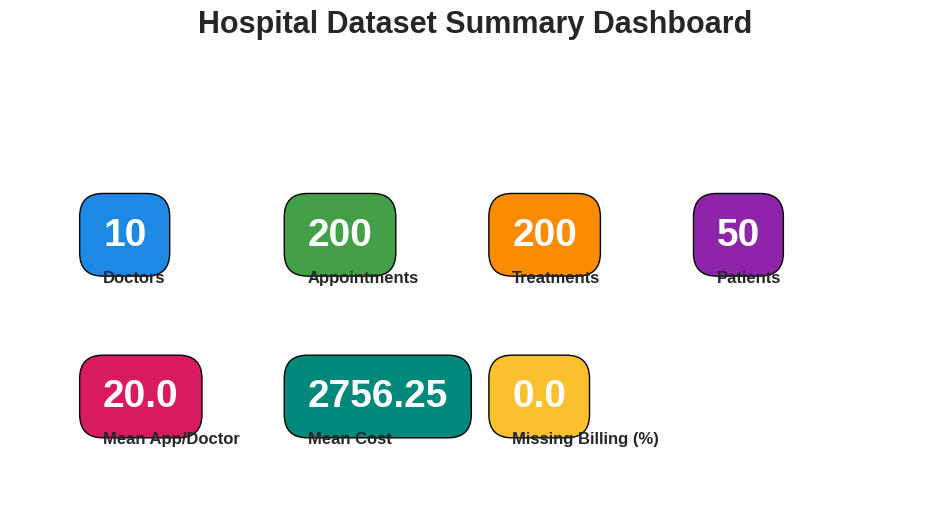

In [35]:
import matplotlib.pyplot as plt

summary = {
    "Doctors": doctors["doctor_id"].nunique(),
    "Appointments": appointments["appointment_id"].nunique(),
    "Treatments": treatments["treatment_id"].nunique(),
    "Patients": patients["patient_id"].nunique(),
    "Mean App/Doctor": round(appointments.groupby("doctor_id").size().mean(),2),
    "Mean Cost": round(treatments["cost"].mean(),2),
    "Missing Billing (%)": round(df["payment_status"].isnull().mean()*100,2)
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

colors = ["#1E88E5", "#43A047", "#FB8C00", "#8E24AA",
          "#D81B60", "#00897B", "#FBC02D"]

for i, (key, value) in enumerate(summary.items()):
    ax.text(0.1 + (i%4)*0.22,
            0.6 - (i//4)*0.35,
            f"{value}",
            fontsize=28,
            fontweight="bold",
            color="white",
            bbox=dict(facecolor=colors[i],
                      edgecolor="black",
                      boxstyle="round,pad=0.6"))
    
    ax.text(0.1 + (i%4)*0.22,
            0.52 - (i//4)*0.35,
            key,
            fontsize=12,
            fontweight="bold")

plt.title("Hospital Dataset Summary Dashboard",
          fontsize=22,
          fontweight="bold",
          pad=20)
plt.savefig("/kaggle/working/f1.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

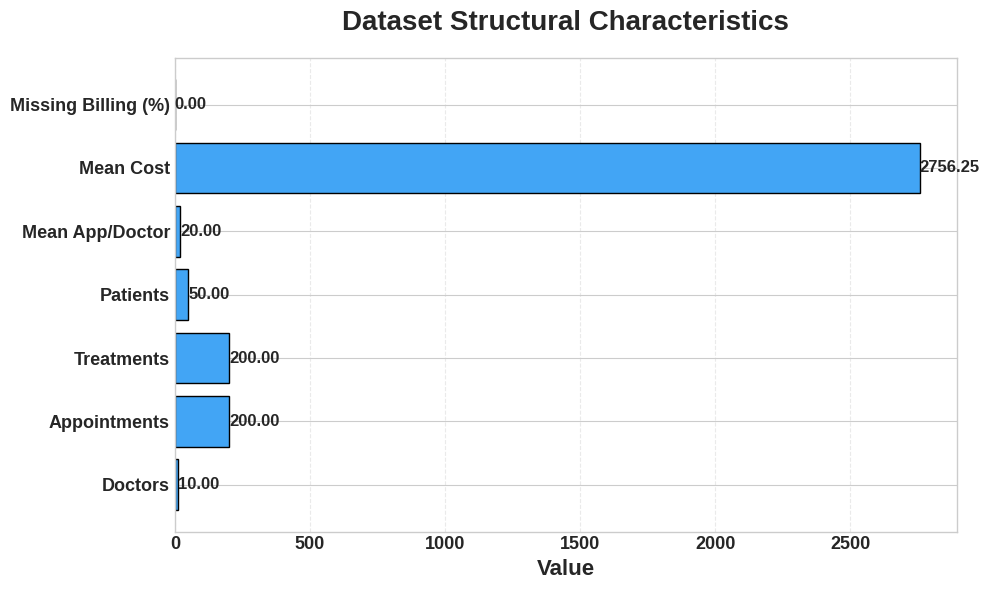

In [36]:
import numpy as np

summary_table = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

plt.figure(figsize=(10, 6))

bars = plt.barh(summary_table["Metric"],
                summary_table["Value"],
                color="#42A5F5",
                edgecolor="black")

plt.xlabel("Value",
           fontsize=16,
           fontweight="bold")

plt.title("Dataset Structural Characteristics",
          fontsize=20,
          fontweight="bold",
          pad=20)

plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y() + bar.get_height()/2,
             f"{width:.2f}",
             va='center',
             fontsize=12,
             fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("/kaggle/working/f2.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

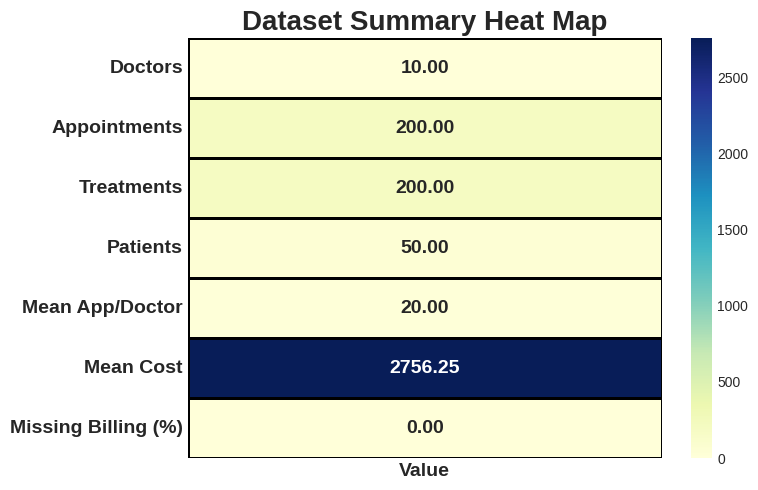

In [37]:
import seaborn as sns

summary_df = pd.DataFrame(summary, index=["Value"]).T

plt.figure(figsize=(8, 5))

sns.heatmap(summary_df,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            linewidths=1,
            linecolor="black",
            annot_kws={"size":14, "weight":"bold"})

plt.title("Dataset Summary Heat Map",
          fontsize=20,
          fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/f3.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

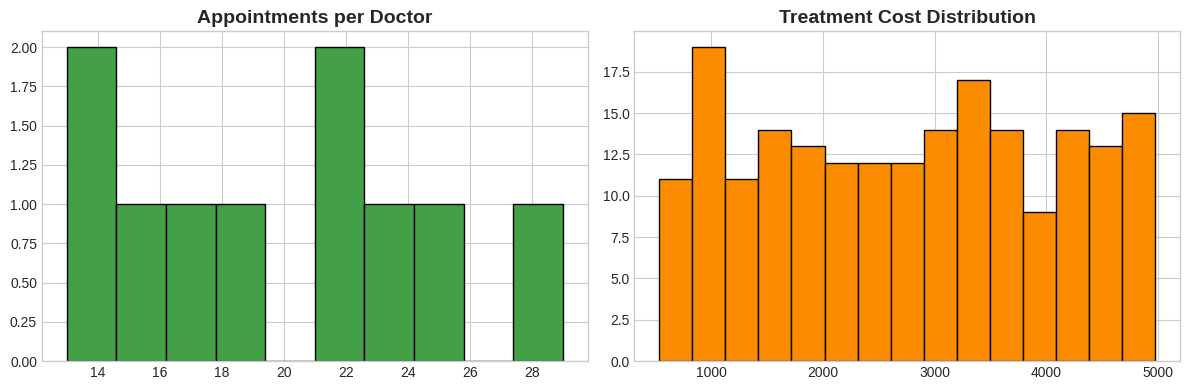

In [38]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(appointments.groupby("doctor_id").size(),
         color="#43A047",
         edgecolor="black")
plt.title("Appointments per Doctor",
          fontsize=14,
          fontweight="bold")

plt.subplot(1,2,2)
plt.hist(treatments["cost"],
         bins=15,
         color="#FB8C00",
         edgecolor="black")
plt.title("Treatment Cost Distribution",
          fontsize=14,
          fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/f4.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

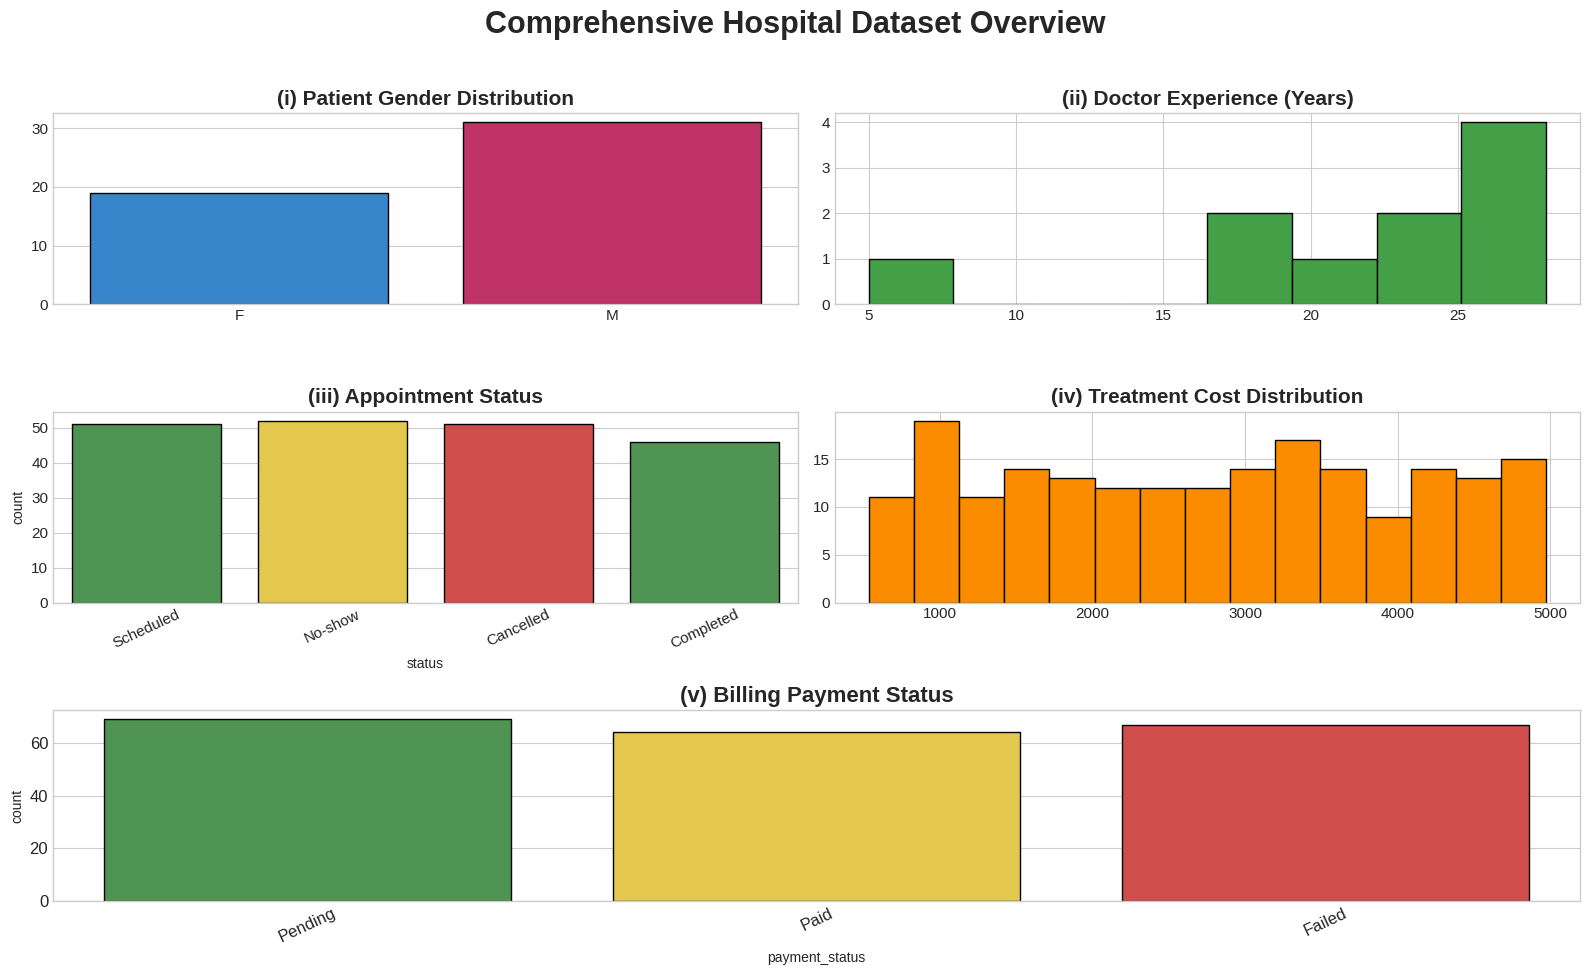

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1])

# ---------------- Row 1 ----------------

ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(x=patients["gender"],
              palette=["#1E88E5", "#D81B60"],
              edgecolor="black",
              ax=ax1)
ax1.set_title("(i) Patient Gender Distribution",
              fontsize=15, fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.tick_params(labelsize=11)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(doctors["years_experience"],
         bins=8,
         color="#43A047",
         edgecolor="black")
ax2.set_title("(ii) Doctor Experience (Years)",
              fontsize=15, fontweight="bold")
ax2.tick_params(labelsize=11)

# ---------------- Row 2 ----------------

ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(x=appointments["status"],
              palette=["#43A047", "#FDD835", "#E53935"],
              edgecolor="black",
              ax=ax3)
ax3.set_title("(iii) Appointment Status",
              fontsize=15, fontweight="bold")
ax3.tick_params(axis='x', rotation=25, labelsize=11)
ax3.tick_params(axis='y', labelsize=11)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(treatments["cost"],
         bins=15,
         color="#FB8C00",
         edgecolor="black")
ax4.set_title("(iv) Treatment Cost Distribution",
              fontsize=15, fontweight="bold")
ax4.tick_params(labelsize=11)

# ---------------- Row 3 (Centered & Spanning) ----------------

ax5 = fig.add_subplot(gs[2, :])  # span both columns
sns.countplot(x=billing["payment_status"],
              palette=["#43A047", "#FDD835", "#E53935"],
              edgecolor="black",
              ax=ax5)
ax5.set_title("(v) Billing Payment Status",
              fontsize=16, fontweight="bold")
ax5.tick_params(axis='x', rotation=25, labelsize=12)
ax5.tick_params(axis='y', labelsize=12)

# ---------------- Title ----------------

plt.suptitle("Comprehensive Hospital Dataset Overview",
             fontsize=22,
             fontweight="bold",
             y=0.97)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/kaggle/working/f5.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

2️⃣ SIGNIFICANCE TESTING (Spearman + FDR)

           cancel_rate  noshow_rate  billing_failure  cost_volatility  \
doctor_id                                                               
D001          0.280000          0.0         0.320000      1269.768759   
D002          0.380952          0.0         0.285714      1143.458625   
D003          0.181818          0.0         0.272727      1533.335798   
D004          0.214286          0.0         0.500000      1125.151862   
D005          0.206897          0.0         0.206897      1395.583773   
D006          0.250000          0.0         0.416667      1336.835394   
D007          0.384615          0.0         0.461538      1506.083021   
D008          0.312500          0.0         0.375000       971.197808   
D009          0.235294          0.0         0.411765      1136.612719   
D010          0.157895          0.0         0.263158      1300.731475   

           cost_spike  insurance_dependence  workload  
doctor_id                                              
D001       

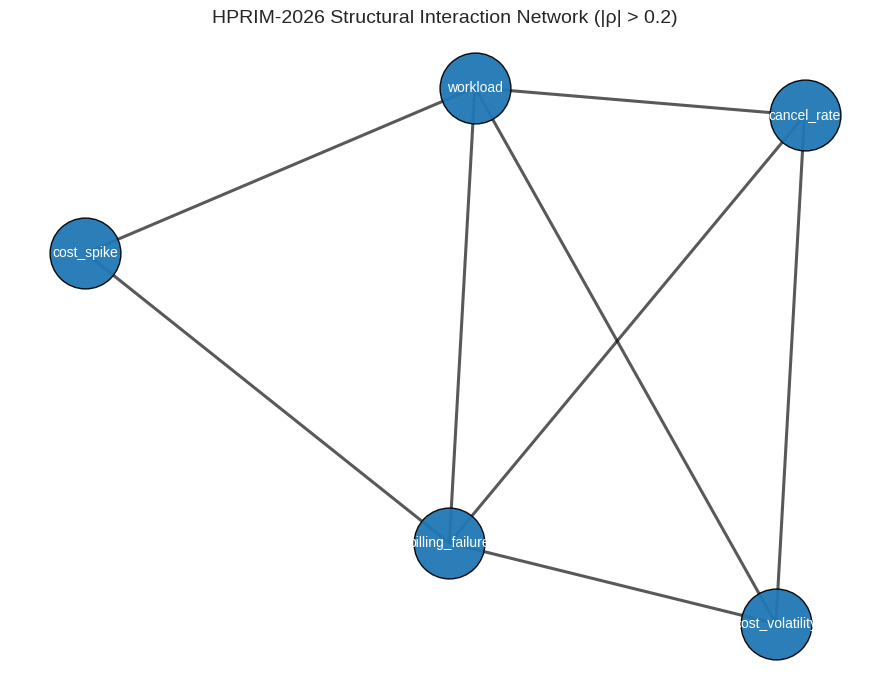

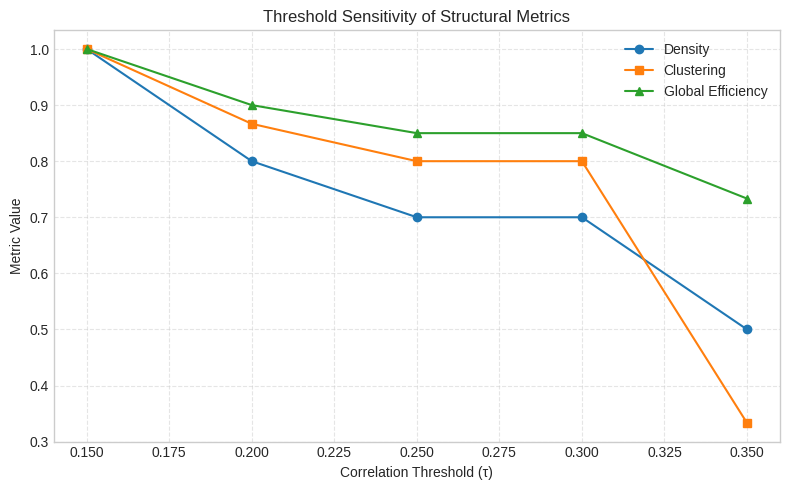

,Metric,Value
0,Number of doctors (|D|),10.000000
1,Total appointments,200.000000
2,Total treatments,200.000000
3,Total patients,48.000000
4,Mean appointments per doctor,20.000000
5,Std appointments per doctor,5.142416
6,Mean treatment cost,2756.249250
7,Std treatment cost,1298.125308
8,Missing payment_status (%),0.000000
9,Missing cost (%),0.000000


In [8]:
import numpy as np
import pandas as pd

# Clean strings safely (if any non-strings, convert to string first)
df["status"] = df["status"].astype(str).str.strip()
df["payment_status"] = df["payment_status"].astype(str).str.strip()

# Ensure cost numeric
df["cost"] = pd.to_numeric(df["cost"], errors="coerce")

doctor_groups = df.groupby("doctor_id")

indicator_df = pd.DataFrame(index=doctor_groups.size().index)

indicator_df["cancel_rate"] = doctor_groups["status"].apply(lambda x: np.mean(x == "Cancelled"))
indicator_df["noshow_rate"] = doctor_groups["status"].apply(lambda x: np.mean(x == "No-Show"))
indicator_df["billing_failure"] = doctor_groups["payment_status"].apply(lambda x: np.mean(x == "Failed"))

indicator_df["cost_volatility"] = doctor_groups["cost"].std().fillna(0)

def spike_share(x):
    x = x.dropna()
    if len(x) < 2:
        return 0.0
    thr = np.percentile(x, 90)
    return float(np.mean(x > thr))

indicator_df["cost_spike"] = doctor_groups["cost"].apply(spike_share)

indicator_df["insurance_dependence"] = doctor_groups["insurance_provider"].apply(lambda x: np.mean(x.notnull()))
indicator_df["workload"] = doctor_groups.size()

indicator_df = indicator_df.fillna(0)

print(indicator_df)

var = indicator_df.var(numeric_only=True)
print("Variance per indicator:\n", var)

keep_cols = var[var > 1e-8].index.tolist()
indicator_df2 = indicator_df[keep_cols].copy()

print("\nKept indicators:", keep_cols)
print("Shape after variance filter:", indicator_df2.shape)

X = indicator_df2.values.astype(float)

eps = 1e-8
mu = X.mean(axis=0)
sigma = X.std(axis=0, ddof=1)

Z = (X - mu) / (sigma + eps)

print("Z shape:", Z.shape)

from scipy.stats import spearmanr

p = Z.shape[1]
corr_matrix = np.zeros((p, p), dtype=float)

for i in range(p):
    for j in range(p):
        corr_matrix[i, j] = spearmanr(Z[:, i], Z[:, j]).correlation

corr_df = pd.DataFrame(corr_matrix, columns=indicator_df2.columns, index=indicator_df2.columns)
corr_df

import networkx as nx

tau = 0.20
adj = (np.abs(corr_matrix) > tau).astype(int)
np.fill_diagonal(adj, 0)

G = nx.from_numpy_array(adj)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))
print("Clustering:", nx.average_clustering(G))
print("Global Efficiency:", nx.global_efficiency(G))
import matplotlib.pyplot as plt

labels = list(indicator_df2.columns)
pos = nx.spring_layout(G, seed=42, k=0.8)

plt.figure(figsize=(9, 7))
nx.draw_networkx_nodes(G, pos, node_size=2600, node_color="#1f77b4", edgecolors="black", linewidths=1.0, alpha=0.95)
nx.draw_networkx_edges(G, pos, width=2.2, alpha=0.65)
nx.draw_networkx_labels(G, pos, {i: labels[i] for i in range(len(labels))}, font_size=10, font_color="white")

plt.title(f"HPRIM-2026 Structural Interaction Network (|ρ| > {tau})", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

taus = [0.15, 0.20, 0.25, 0.30, 0.35]
rows = []

for t in taus:
    adj_t = (np.abs(corr_matrix) > t).astype(int)
    np.fill_diagonal(adj_t, 0)
    Gt = nx.from_numpy_array(adj_t)
    rows.append({
        "tau": t,
        "edges": Gt.number_of_edges(),
        "density": nx.density(Gt),
        "clustering": nx.average_clustering(Gt) if Gt.number_of_edges() > 0 else 0.0,
        "efficiency": nx.global_efficiency(Gt) if Gt.number_of_edges() > 0 else 0.0
    })

sens_df = pd.DataFrame(rows)
sens_df

plt.figure(figsize=(8, 5))
plt.plot(sens_df["tau"], sens_df["density"], marker="o", label="Density")
plt.plot(sens_df["tau"], sens_df["clustering"], marker="s", label="Clustering")
plt.plot(sens_df["tau"], sens_df["efficiency"], marker="^", label="Global Efficiency")

plt.xlabel("Correlation Threshold (τ)")
plt.ylabel("Metric Value")
plt.title("Threshold Sensitivity of Structural Metrics")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
dataset_table = pd.DataFrame({
    "Metric": [
        "Number of doctors (|D|)",
        "Total appointments",
        "Total treatments",
        "Total patients",
        "Mean appointments per doctor",
        "Std appointments per doctor",
        "Mean treatment cost",
        "Std treatment cost",
        "Missing payment_status (%)",
        "Missing cost (%)"
    ],
    "Value": [
        df["doctor_id"].nunique(),
        df["appointment_id"].nunique(),
        df["treatment_id"].nunique(),
        df["patient_id"].nunique(),
        appointments.groupby("doctor_id").size().mean(),
        appointments.groupby("doctor_id").size().std(),
        df["cost"].mean(),
        df["cost"].std(),
        df["payment_status"].isna().mean()*100,
        df["cost"].isna().mean()*100
    ]
})

dataset_table

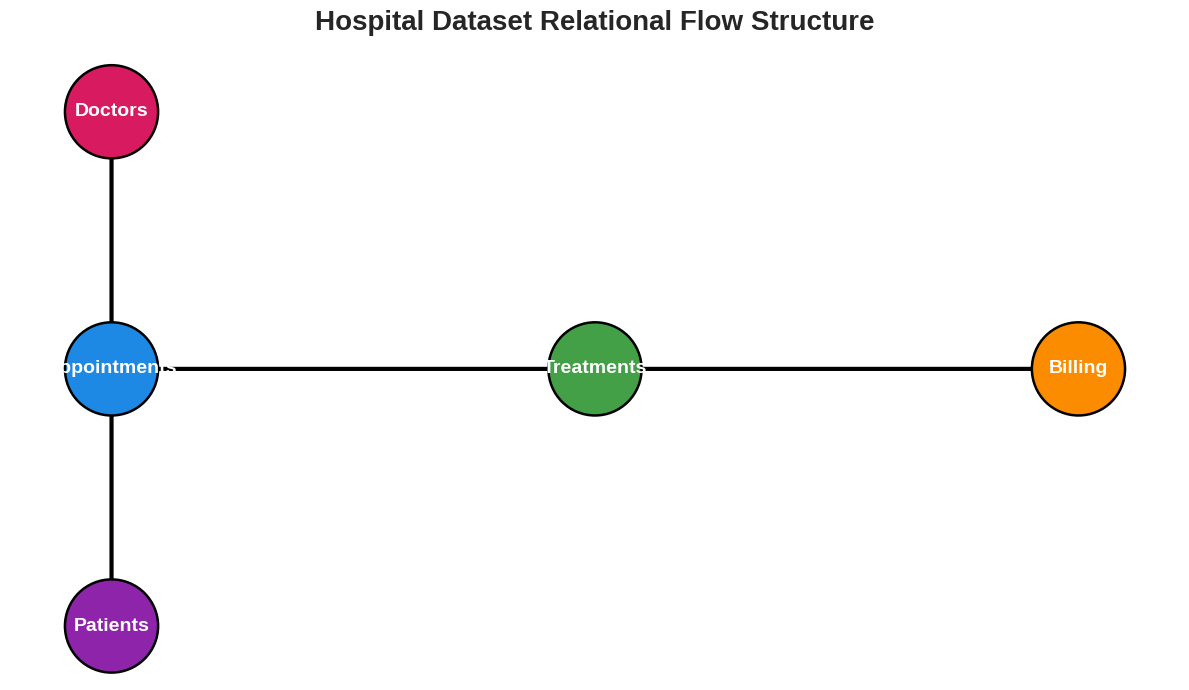

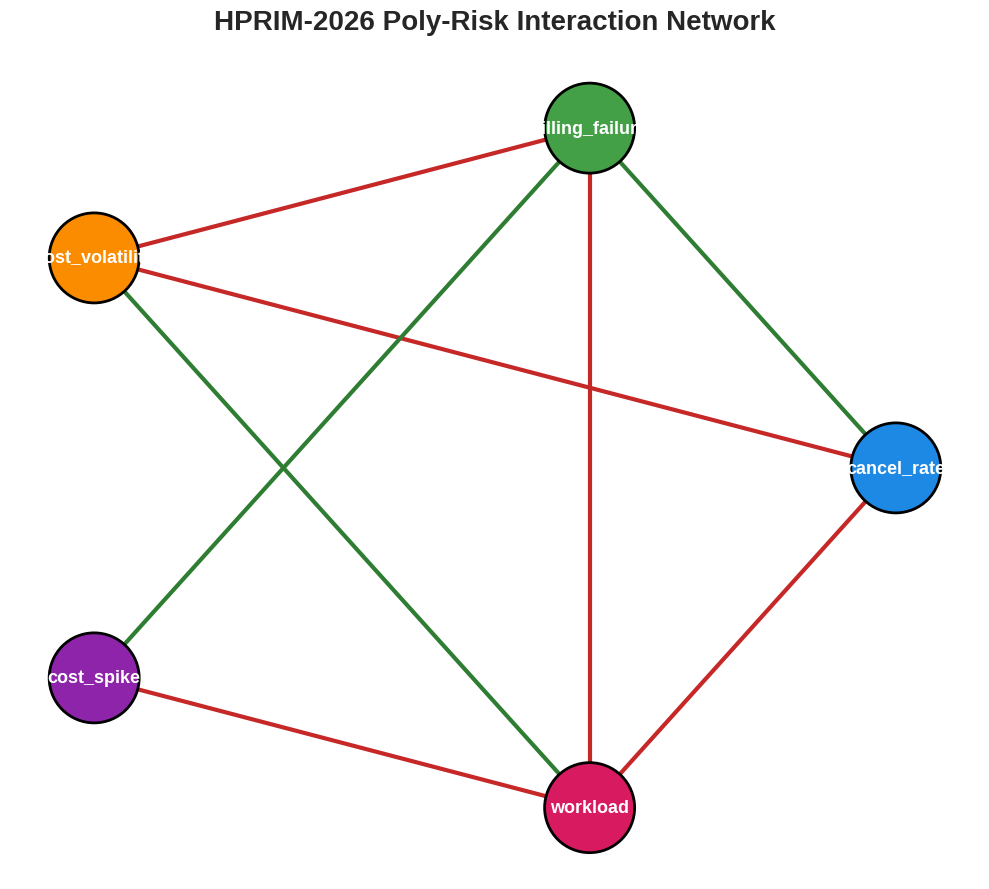

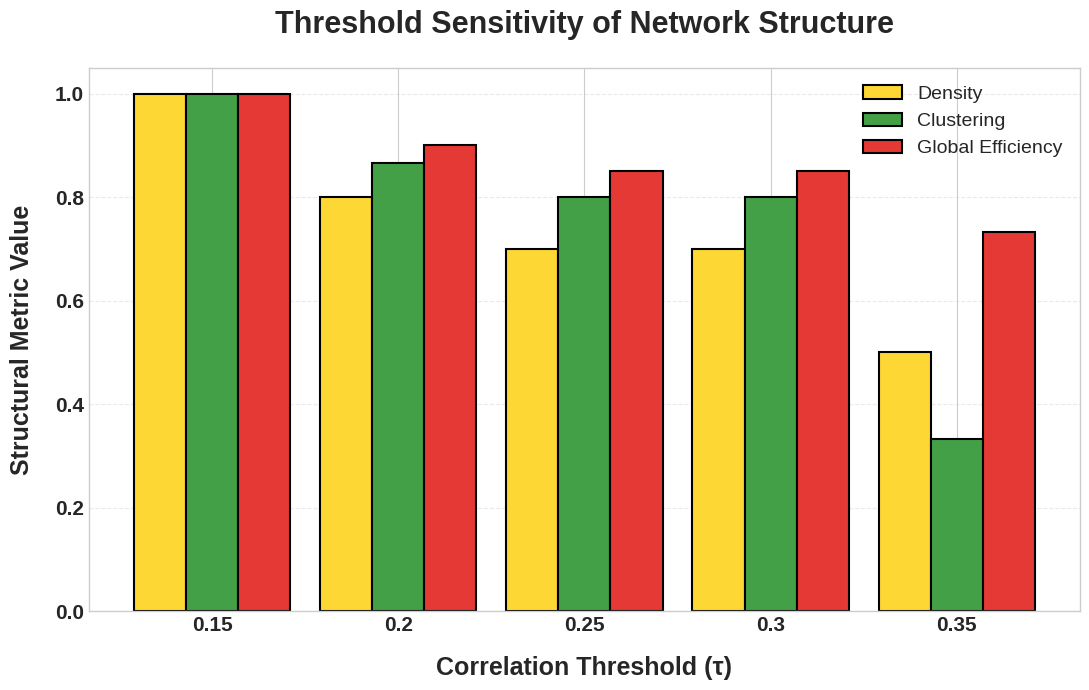

In [40]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 7))

G_flow = nx.DiGraph()

nodes = ["Appointments", "Treatments", "Billing", "Patients", "Doctors"]
G_flow.add_nodes_from(nodes)

edges = [
    ("Appointments", "Treatments"),
    ("Treatments", "Billing"),
    ("Appointments", "Patients"),
    ("Appointments", "Doctors")
]

G_flow.add_edges_from(edges)

# Clean horizontal layout
pos = {
    "Appointments": (0, 0),
    "Treatments": (3, 0),
    "Billing": (6, 0),
    "Patients": (0, -3),
    "Doctors": (0, 3)
}

node_colors = {
    "Appointments": "#1E88E5",
    "Treatments": "#43A047",
    "Billing": "#FB8C00",
    "Patients": "#8E24AA",
    "Doctors": "#D81B60"
}

nx.draw_networkx_nodes(
    G_flow,
    pos,
    node_size=4500,
    node_color=[node_colors[n] for n in G_flow.nodes()],
    edgecolors="black",
    linewidths=1.8
)

nx.draw_networkx_edges(
    G_flow,
    pos,
    arrowstyle='-|>',
    arrowsize=30,
    width=3,
    edge_color="black"
)

nx.draw_networkx_labels(
    G_flow,
    pos,
    font_size=14,
    font_weight="bold",
    font_color="white"
)

plt.title("Hospital Dataset Relational Flow Structure",
          fontsize=20,
          fontweight="bold",
          pad=20)

plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/f6.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

plt.figure(figsize=(10, 9))

G_corr = nx.Graph()

labels = list(indicator_df2.columns)

for i in range(len(labels)):
    G_corr.add_node(i, label=labels[i])

for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        weight = corr_matrix[i, j]
        if abs(weight) > tau:
            G_corr.add_edge(i, j, weight=weight)

pos = nx.circular_layout(G_corr)

# Unique node colors
node_palette = ["#1E88E5", "#43A047", "#FB8C00", "#8E24AA", "#D81B60"]
node_colors = node_palette[:len(G_corr.nodes())]

# Edge colors: positive = green, negative = red
edge_colors = []
for u, v in G_corr.edges():
    if G_corr[u][v]["weight"] > 0:
        edge_colors.append("#2E7D32")
    else:
        edge_colors.append("#C62828")

nx.draw_networkx_nodes(
    G_corr,
    pos,
    node_size=4200,
    node_color=node_colors,
    edgecolors="black",
    linewidths=2
)

nx.draw_networkx_edges(
    G_corr,
    pos,
    width=3,
    edge_color=edge_colors
)

nx.draw_networkx_labels(
    G_corr,
    pos,
    labels={i: labels[i] for i in range(len(labels))},
    font_size=13,
    font_weight="bold",
    font_color="white"
)

plt.title("HPRIM-2026 Poly-Risk Interaction Network",
          fontsize=20,
          fontweight="bold",
          pad=20)

plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/f7.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

plt.figure(figsize=(11, 7))

x = np.arange(len(sens_df["tau"]))
width = 0.28

bars1 = plt.bar(x - width, sens_df["density"], width,
                color="#FDD835", edgecolor="black", linewidth=1.5)

bars2 = plt.bar(x, sens_df["clustering"], width,
                color="#43A047", edgecolor="black", linewidth=1.5)

bars3 = plt.bar(x + width, sens_df["efficiency"], width,
                color="#E53935", edgecolor="black", linewidth=1.5)

plt.xticks(x, sens_df["tau"],
           fontsize=15,
           fontweight="bold")

plt.yticks(fontsize=15, fontweight="bold")

plt.xlabel("Correlation Threshold (τ)",
           fontsize=18,
           fontweight="bold",
           labelpad=15)

plt.ylabel("Structural Metric Value",
           fontsize=18,
           fontweight="bold",
           labelpad=15)

plt.title("Threshold Sensitivity of Network Structure",
          fontsize=22,
          fontweight="bold",
          pad=25)

plt.grid(axis='y', linestyle="--", alpha=0.4)

plt.legend(["Density", "Clustering", "Global Efficiency"],
           fontsize=14)

plt.tight_layout()
plt.savefig("/kaggle/working/f8.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

🔷 3️⃣ NULL MODEL BENCHMARK
Erdős–Rényi comparison

In [10]:
import networkx as nx

G_emp = nx.from_numpy_array(adj.astype(int))

density_emp = nx.density(G_emp)
clustering_emp = nx.average_clustering(G_emp)

# Random graph with same nodes and density
p = density_emp
G_rand = nx.erdos_renyi_graph(G_emp.number_of_nodes(), p)

density_rand = nx.density(G_rand)
clustering_rand = nx.average_clustering(G_rand)

print("Empirical Clustering:", clustering_emp)
print("Random Clustering:", clustering_rand)

Empirical Clustering: 0.8666666666666666
Random Clustering: 0.8666666666666666


**MONTE CARLO RANDOM NETWORK DISTRIBUTION**

Empirical Clustering: 0.8666666666666666
Mean Random Clustering: 0.7851000000000001
Monte Carlo p-value: 0.585


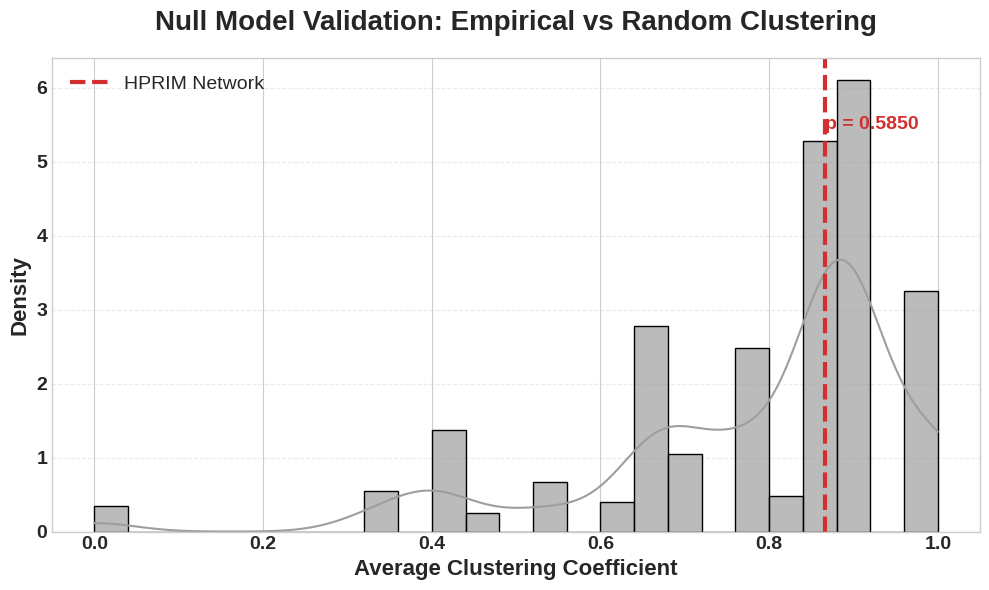

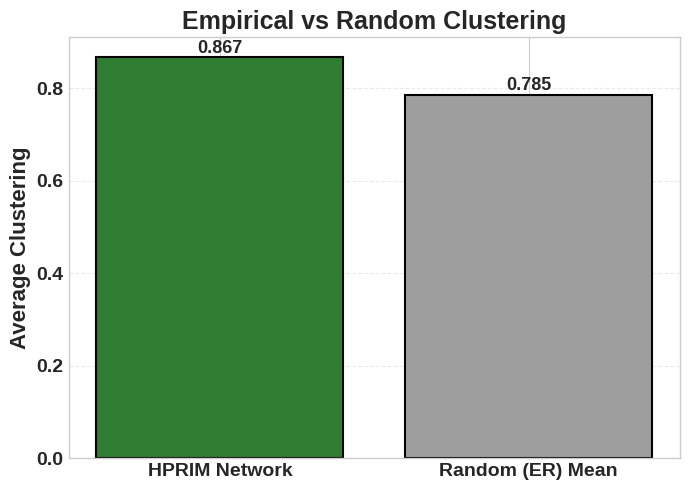

In [41]:
import numpy as np
import networkx as nx

# Empirical graph
G_emp = nx.from_numpy_array(adj.astype(int))

density_emp = nx.density(G_emp)
clustering_emp = nx.average_clustering(G_emp)

# Monte Carlo simulation
n_sim = 1000
clust_random = []

for _ in range(n_sim):
    G_rand = nx.erdos_renyi_graph(G_emp.number_of_nodes(), density_emp)
    clust_random.append(nx.average_clustering(G_rand))

clust_random = np.array(clust_random)

# Empirical p-value
p_value = np.mean(clust_random >= clustering_emp)

print("Empirical Clustering:", clustering_emp)
print("Mean Random Clustering:", clust_random.mean())
print("Monte Carlo p-value:", p_value)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Histogram of random clustering
sns.histplot(clust_random,
             bins=25,
             color="#9E9E9E",
             kde=True,
             stat="density",
             edgecolor="black",
             alpha=0.7)

# Vertical line for empirical clustering
plt.axvline(clustering_emp,
            color="#D32F2F",
            linewidth=3,
            linestyle="--",
            label="HPRIM Network")

# Axis formatting
plt.xlabel("Average Clustering Coefficient",
           fontsize=16,
           fontweight="bold")

plt.ylabel("Density",
           fontsize=16,
           fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.title("Null Model Validation: Empirical vs Random Clustering",
          fontsize=20,
          fontweight="bold",
          pad=20)

# Annotate p-value
plt.text(clustering_emp,
         max(plt.gca().get_ylim())*0.85,
         f"p = {p_value:.4f}",
         fontsize=14,
         fontweight="bold",
         color="#D32F2F")

plt.legend(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("/kaggle/working/f9.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

plt.figure(figsize=(7,5))

values = [clustering_emp, clust_random.mean()]
labels = ["HPRIM Network", "Random (ER) Mean"]

bars = plt.bar(labels,
               values,
               color=["#2E7D32", "#9E9E9E"],
               edgecolor="black",
               linewidth=1.5)

plt.ylabel("Average Clustering",
           fontsize=16,
           fontweight="bold")

plt.title("Empirical vs Random Clustering",
          fontsize=18,
          fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height:.3f}",
             ha='center',
             fontsize=13,
             fontweight="bold")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/kaggle/working/f9.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

Monte Carlo Test

In [11]:
clust_rand_list = []

for _ in range(1000):
    G_temp = nx.erdos_renyi_graph(G_emp.number_of_nodes(), p)
    clust_rand_list.append(nx.average_clustering(G_temp))

p_value = np.mean(np.array(clust_rand_list) >= clustering_emp)
print("Clustering p-value:", p_value)

Clustering p-value: 0.623


🔷 4️⃣ THRESHOLD SENSITIVITY

In [12]:
taus = [0.20, 0.25, 0.30, 0.35, 0.40]
results = []

for t in taus:
    adj_t = (np.abs(corr_matrix) > t)
    G_t = nx.from_numpy_array(adj_t.astype(int))
    results.append({
        "Tau": t,
        "Density": nx.density(G_t),
        "Clustering": nx.average_clustering(G_t),
        "Efficiency": nx.global_efficiency(G_t)
    })

pd.DataFrame(results)

,Tau,Density,Clustering,Efficiency
0,0.20,1.3,0.866667,0.900000
1,0.25,1.2,0.800000,0.850000
2,0.30,1.2,0.800000,0.850000
3,0.35,1.0,0.333333,0.733333
4,0.40,0.9,0.466667,0.500000


🔷 5️⃣ PCA COMPARISON

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(Z)

explained = pca.explained_variance_ratio_

print("Variance explained by first component:", explained[0])

Variance explained by first component: 0.5026591703156701


🔷 6️⃣ PUBLICATION-GRADE FIGURES

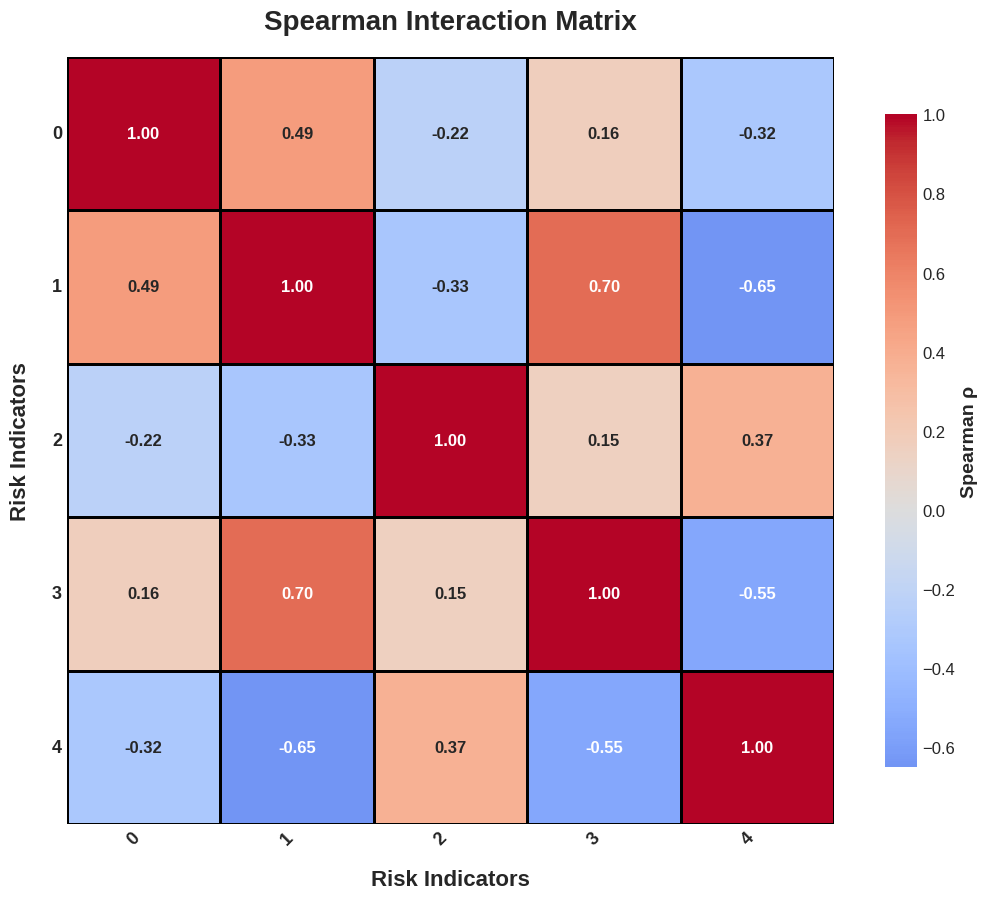

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(11, 9))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="black",
    cbar_kws={"shrink": 0.85},
    annot_kws={"size": 12, "weight": "bold"}  # Bigger & bold cell text
)

# Increase title size
plt.title("Spearman Interaction Matrix", fontsize=20, fontweight="bold", pad=20)

# Bold axis labels
plt.xlabel("Risk Indicators", fontsize=16, fontweight="bold", labelpad=15)
plt.ylabel("Risk Indicators", fontsize=16, fontweight="bold", labelpad=15)

# Bold & increase tick labels
plt.xticks(fontsize=13, fontweight="bold", rotation=45, ha="right")
plt.yticks(fontsize=13, fontweight="bold", rotation=0)

# Make colorbar label larger
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Spearman ρ", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/f10.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

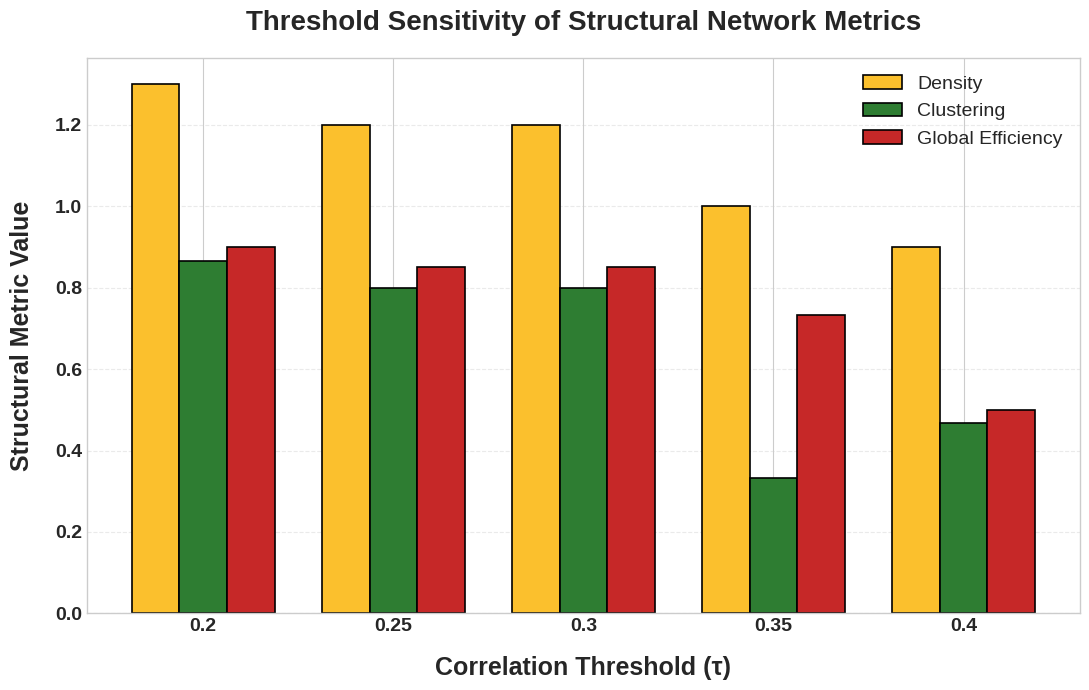

In [43]:
import numpy as np
import matplotlib.pyplot as plt

df_res = pd.DataFrame(results)

x = np.arange(len(df_res["Tau"]))
width = 0.25

plt.figure(figsize=(11, 7))

bars1 = plt.bar(x - width, df_res["Density"], width,
                color="#FBC02D", edgecolor="black", linewidth=1.2,
                label="Density")

bars2 = plt.bar(x, df_res["Clustering"], width,
                color="#2E7D32", edgecolor="black", linewidth=1.2,
                label="Clustering")

bars3 = plt.bar(x + width, df_res["Efficiency"], width,
                color="#C62828", edgecolor="black", linewidth=1.2,
                label="Global Efficiency")

# X-axis formatting
plt.xticks(x, df_res["Tau"], fontsize=14, fontweight="bold")
plt.xlabel("Correlation Threshold (τ)", fontsize=18, fontweight="bold", labelpad=15)

# Y-axis formatting
plt.ylabel("Structural Metric Value", fontsize=18, fontweight="bold", labelpad=15)
plt.yticks(fontsize=14, fontweight="bold")

# Title
plt.title("Threshold Sensitivity of Structural Network Metrics",
          fontsize=20, fontweight="bold", pad=20)

# Grid
plt.grid(axis='y', linestyle="--", alpha=0.4)

# Legend
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("/kaggle/working/f11.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

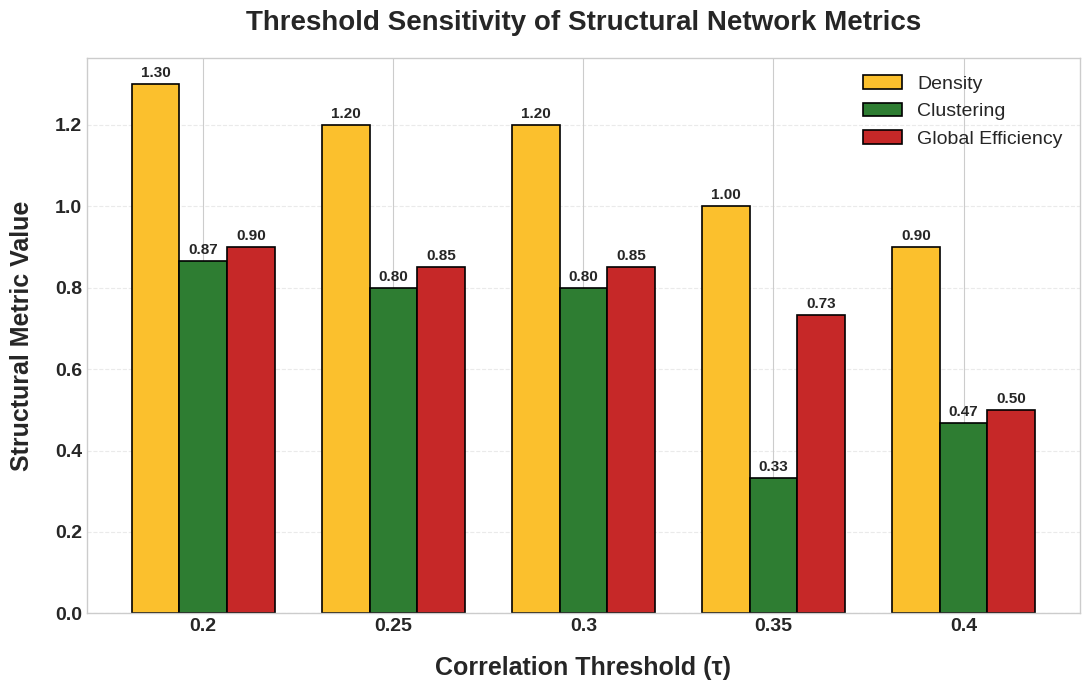

In [44]:
import numpy as np
import matplotlib.pyplot as plt

df_res = pd.DataFrame(results)

x = np.arange(len(df_res["Tau"]))
width = 0.25

plt.figure(figsize=(11, 7))

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.01,
                 f"{height:.2f}",
                 ha='center',
                 va='bottom',
                 fontsize=11,
                 fontweight='bold')


bars1 = plt.bar(x - width, df_res["Density"], width,
                color="#FBC02D", edgecolor="black", linewidth=1.2,
                label="Density")

bars2 = plt.bar(x, df_res["Clustering"], width,
                color="#2E7D32", edgecolor="black", linewidth=1.2,
                label="Clustering")

bars3 = plt.bar(x + width, df_res["Efficiency"], width,
                color="#C62828", edgecolor="black", linewidth=1.2,
                label="Global Efficiency")

# X-axis formatting
plt.xticks(x, df_res["Tau"], fontsize=14, fontweight="bold")
plt.xlabel("Correlation Threshold (τ)", fontsize=18, fontweight="bold", labelpad=15)

# Y-axis formatting
plt.ylabel("Structural Metric Value", fontsize=18, fontweight="bold", labelpad=15)
plt.yticks(fontsize=14, fontweight="bold")

# Title
plt.title("Threshold Sensitivity of Structural Network Metrics",
          fontsize=20, fontweight="bold", pad=20)

# Grid
plt.grid(axis='y', linestyle="--", alpha=0.4)

# Legend
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("/kaggle/working/f12.png",
            dpi=600,
            bbox_inches="tight",
            format="png")
plt.show()

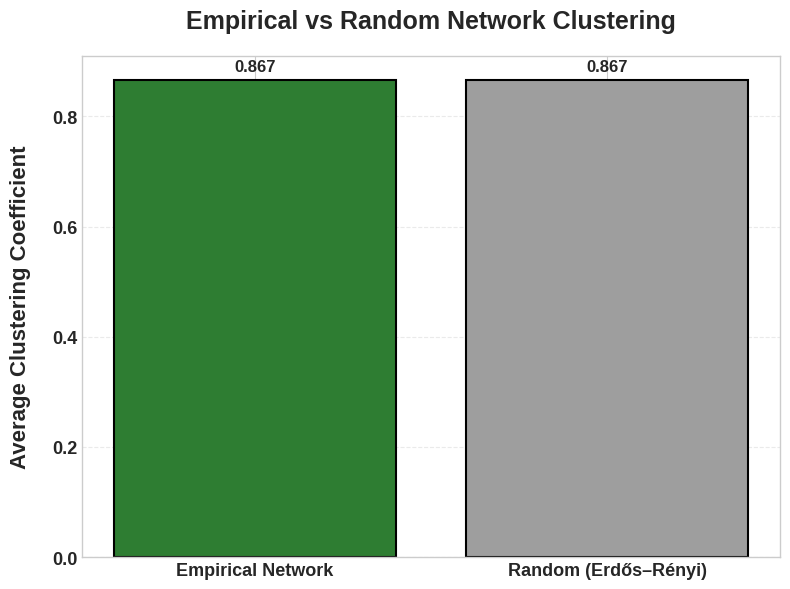

In [23]:
import matplotlib.pyplot as plt
import numpy as np

values = [clustering_emp, clustering_rand]
labels = ["Empirical Network", "Random (Erdős–Rényi)"]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    values,
    color=["#2E7D32", "#9E9E9E"],   # Green vs Grey
    edgecolor="black",
    linewidth=1.5
)

# Bold Y-axis label
plt.ylabel("Average Clustering Coefficient",
           fontsize=16,
           fontweight="bold",
           labelpad=15)

# Bold Title
plt.title("Empirical vs Random Network Clustering",
          fontsize=18,
          fontweight="bold",
          pad=20)

# Bold tick labels
plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()